In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv('eurusd_hour.csv')

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set as index and sort
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Display information
print("HEAD:")
print(df.head())
print("\nINFO:")
print(df.info())
print("\nMISSING VALUES:")
print(df.isnull().sum())

Saving eurusd_hour.csv to eurusd_hour (1).csv
HEAD:
             Time      BO      BH      BL      BC     BCh      AO      AH  \
Date                                                                        
2005-05-02  00:00  1.2852  1.2852  1.2840  1.2844 -0.0008  1.2854  1.2854   
2005-05-02  01:00  1.2844  1.2848  1.2839  1.2842 -0.0002  1.2846  1.2850   
2005-05-02  02:00  1.2843  1.2854  1.2841  1.2851  0.0008  1.2845  1.2856   
2005-05-02  03:00  1.2851  1.2859  1.2850  1.2851  0.0000  1.2853  1.2861   
2005-05-02  04:00  1.2852  1.2859  1.2849  1.2855  0.0003  1.2854  1.2861   

                AL      AC     ACh  
Date                                
2005-05-02  1.2842  1.2846 -0.0008  
2005-05-02  1.2841  1.2844 -0.0002  
2005-05-02  1.2843  1.2853  0.0008  
2005-05-02  1.2852  1.2853  0.0000  
2005-05-02  1.2851  1.2857  0.0003  

INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 93084 entries, 2005-05-02 to 2020-04-29
Data columns (total 11 columns):
 #   Column  Non

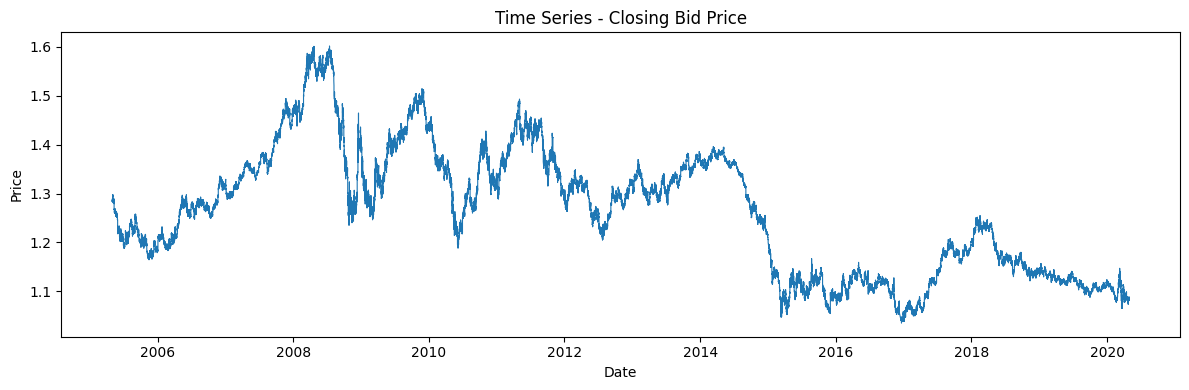

Missing Values:
Time    0
BO      0
BH      0
BL      0
BC      0
BCh     0
AO      0
AH      0
AL      0
AC      0
ACh     0
dtype: int64

Missing Values Percentage:
Time    0.0
BO      0.0
BH      0.0
BL      0.0
BC      0.0
BCh     0.0
AO      0.0
AH      0.0
AL      0.0
AC      0.0
ACh     0.0
dtype: float64

After handling missing values:
Time    0
BO      0
BH      0
BL      0
BC      0
BCh     0
AO      0
AH      0
AL      0
AC      0
ACh     0
dtype: int64


/tmp/ipykernel_12014/2068069798.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



Duplicate rows: 0
Duplicate indices: 88412


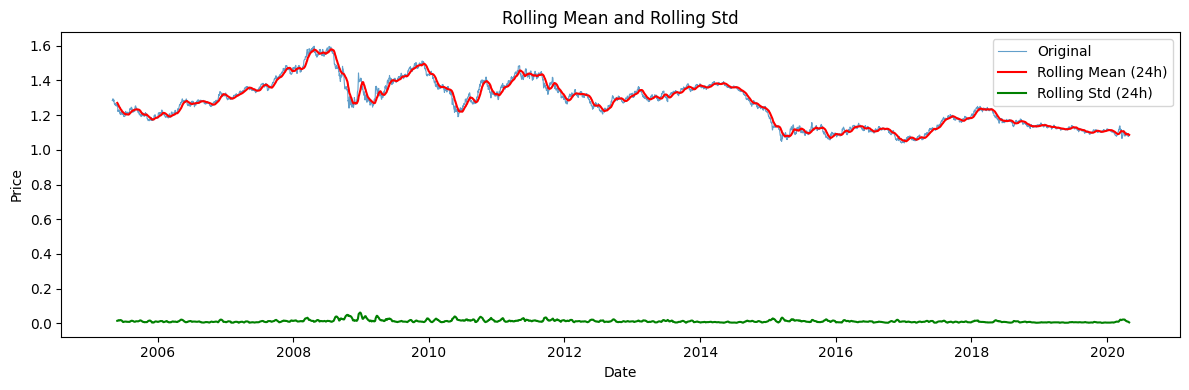


ADF Test Results for Closing Bid Price:
ADF Statistic: -1.635875
P-value: 0.464417
Critical Values:
  1%: -3.432
  5%: -2.862
  10%: -2.567
Result: Non-stationary (Fail to reject null hypothesis)

ADF Test Results for First Difference of Closing Bid Price:
ADF Statistic: -67.921853
P-value: 0.000000
Critical Values:
  1%: -3.432
  5%: -2.862
  10%: -2.567
Result: Stationary (Reject null hypothesis)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Assuming df is already loaded from previous step

# 1. Plot time series
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['BC'], linewidth=0.8)
plt.title('Time Series - Closing Bid Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# 2. Check and handle missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Handle missing values (forward fill)
df.fillna(method='ffill', inplace=True)
print("\nAfter handling missing values:")
print(df.isnull().sum())

# 3. Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate indices: {df.index.duplicated().sum()}")
df = df[~df.duplicated(keep='first')]
df = df[~df.index.duplicated(keep='first')]

# 4. Plot rolling mean and rolling std
window = 24  # 24-hour rolling window
rolling_mean = df['BC'].rolling(window=window).mean()
rolling_std = df['BC'].rolling(window=window).std()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['BC'], label='Original', linewidth=0.8, alpha=0.7)
plt.plot(df.index, rolling_mean, label=f'Rolling Mean ({window}h)', linewidth=1.5, color='red')
plt.plot(df.index, rolling_std, label=f'Rolling Std ({window}h)', linewidth=1.5, color='green')
plt.title('Rolling Mean and Rolling Std')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# 5. ADF Test for Stationarity
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\nADF Test Results for {name}:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'P-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.3f}')

    if result[1] <= 0.05:
        print('Result: Stationary (Reject null hypothesis)')
    else:
        print('Result: Non-stationary (Fail to reject null hypothesis)')

adf_test(df['BC'], 'Closing Bid Price')

# Test differencing for stationarity
df['BC_diff'] = df['BC'].diff()
adf_test(df['BC_diff'], 'First Difference of Closing Bid Price')

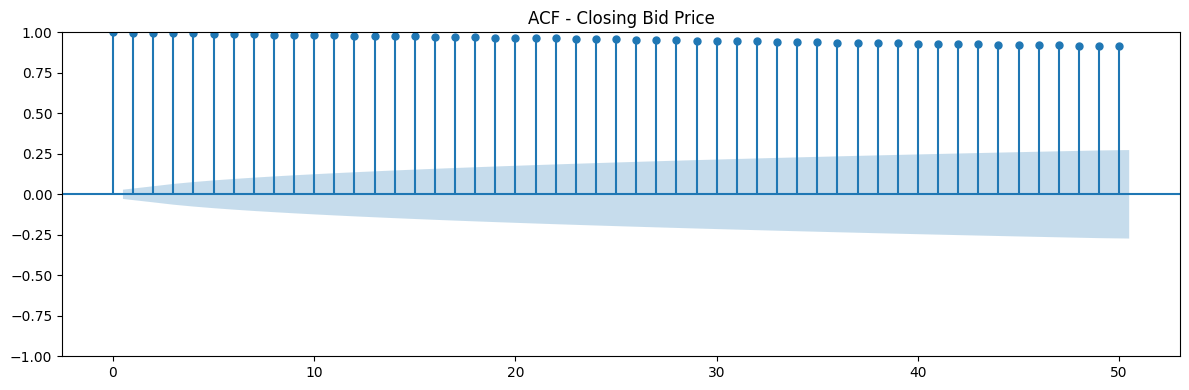

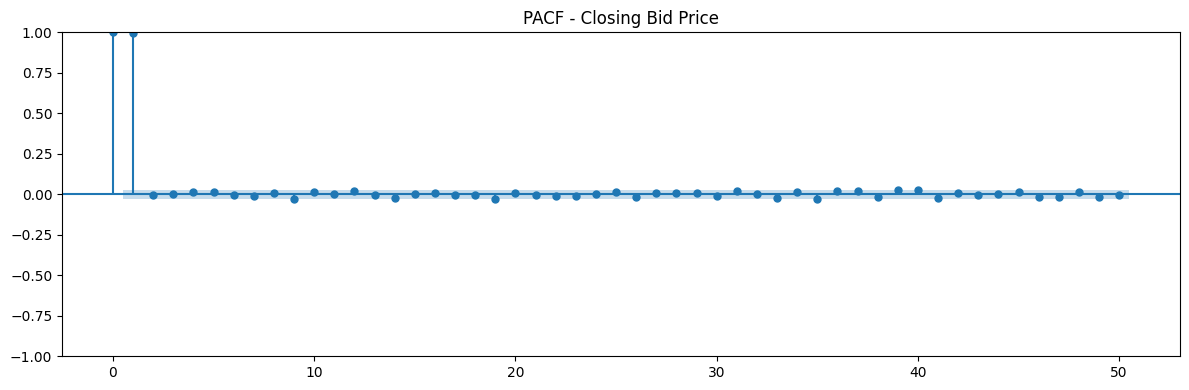

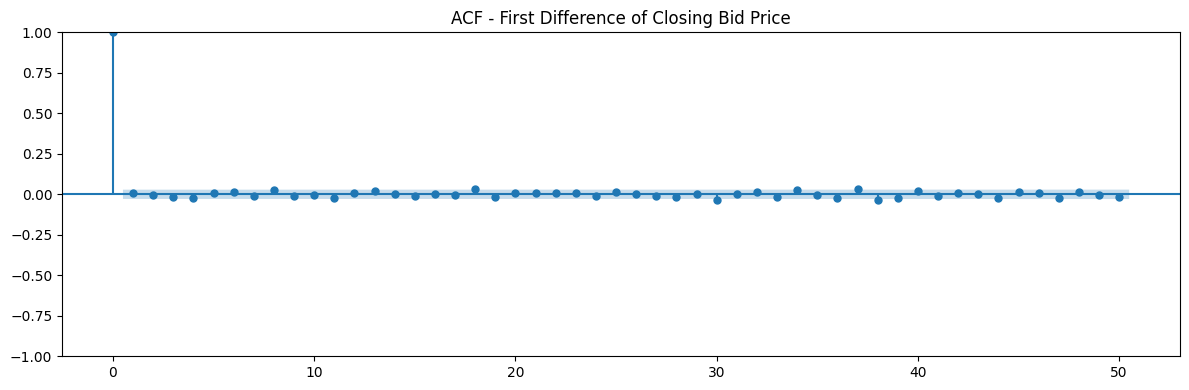

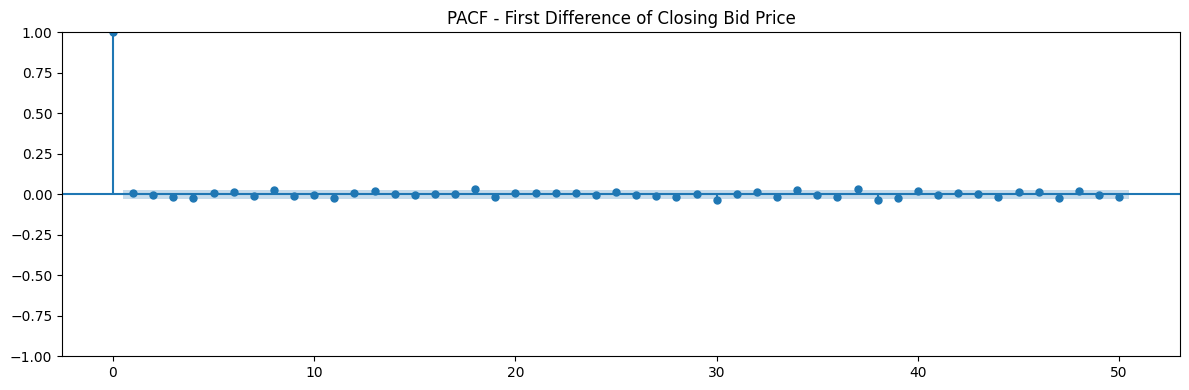

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assuming df is already loaded from previous steps

# 1. Plot ACF
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['BC'].dropna(), lags=50, ax=ax)
plt.title('ACF - Closing Bid Price')
plt.tight_layout()
plt.show()

# 2. Plot PACF
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df['BC'].dropna(), lags=50, ax=ax)
plt.title('PACF - Closing Bid Price')
plt.tight_layout()
plt.show()

# ACF and PACF for differenced series
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['BC_diff'].dropna(), lags=50, ax=ax)
plt.title('ACF - First Difference of Closing Bid Price')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df['BC_diff'].dropna(), lags=50, ax=ax)
plt.title('PACF - First Difference of Closing Bid Price')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

# Assuming df is already loaded from previous steps

# Prepare data
data = df['BC'].dropna()
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}\n")

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    return rmse

# 1. AR Model (AutoReg with lag order 1)
ar_model = AutoReg(train, lags=1)
ar_fitted = ar_model.fit()
ar_pred = ar_fitted.get_prediction(start=len(train), end=len(data)-1).predicted_mean
ar_rmse = calculate_rmse(test, ar_pred)
print(f"AR Model RMSE: {ar_rmse:.6f}")

# 2. MA Model (ARIMA with order (0, 0, 1))
ma_model = ARIMA(train, order=(0, 0, 1))
ma_fitted = ma_model.fit()
ma_pred = ma_fitted.get_forecast(steps=len(test)).predicted_mean
ma_rmse = calculate_rmse(test, ma_pred)
print(f"MA Model RMSE: {ma_rmse:.6f}")

# 3. ARMA Model (ARIMA with order (1, 0, 1))
arma_model = ARIMA(train, order=(1, 0, 1))
arma_fitted = arma_model.fit()
arma_pred = arma_fitted.get_forecast(steps=len(test)).predicted_mean
arma_rmse = calculate_rmse(test, arma_pred)
print(f"ARMA Model RMSE: {arma_rmse:.6f}")

# 4. ARIMA Model (ARIMA with order (1, 1, 1))
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fitted = arima_model.fit()
arima_pred = arima_fitted.get_forecast(steps=len(test)).predicted_mean
arima_rmse = calculate_rmse(test, arima_pred)
print(f"ARIMA Model RMSE: {arima_rmse:.6f}")

print("\n" + "="*40)
print("Summary:")
print("="*40)
print(f"AR(1)     RMSE: {ar_rmse:.6f}")
print(f"MA(1)     RMSE: {ma_rmse:.6f}")
print(f"ARMA(1,1) RMSE: {arma_rmse:.6f}")
print(f"ARIMA(1,1,1) RMSE: {arima_rmse:.6f}")

Train size: 3737, Test size: 935

AR Model RMSE: 0.072384


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the po

MA Model RMSE: 0.154452


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

ARMA Model RMSE: 0.085549
ARIMA Model RMSE: 0.070005

Summary:
AR(1)     RMSE: 0.072384
MA(1)     RMSE: 0.154452
ARMA(1,1) RMSE: 0.085549
ARIMA(1,1,1) RMSE: 0.070005


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming df is already loaded from previous steps

# Prepare data
data = df['BC'].dropna()
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}\n")

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    return rmse

# 1. SARIMA Model
# order=(p, d, q), seasonal_order=(P, D, Q, s)
# For hourly forex data, seasonal period = 24
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
sarima_fitted = sarima_model.fit(disp=False)
sarima_pred = sarima_fitted.get_forecast(steps=len(test)).predicted_mean
sarima_rmse = calculate_rmse(test, sarima_pred)
print(f"SARIMA(1,1,1)x(1,1,1,24) RMSE: {sarima_rmse:.6f}")

# 2. SARIMAX Model with exogenous variables
# Using other price columns as exogenous variables
exog_cols = ['BO', 'BH', 'BL', 'AO', 'AH', 'AL']
exog_available = [col for col in exog_cols if col in df.columns]

if exog_available:
    print(f"\nExogenous variables used: {exog_available}")
    exog_train = df[exog_available].iloc[:train_size]
    exog_test = df[exog_available].iloc[train_size:]

    sarimax_model = SARIMAX(train, exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
    sarimax_fitted = sarimax_model.fit(disp=False)
    sarimax_pred = sarimax_fitted.get_forecast(steps=len(test), exog=exog_test).predicted_mean
    sarimax_rmse = calculate_rmse(test, sarimax_pred)
    print(f"SARIMAX(1,1,1)x(1,1,1,24) RMSE: {sarimax_rmse:.6f}")
else:
    print("\nNo exogenous variables available for SARIMAX")

print("\n" + "="*50)
print("Summary:")
print("="*50)
print(f"SARIMA(1,1,1)x(1,1,1,24) RMSE:  {sarima_rmse:.6f}")
if exog_available:
    print(f"SARIMAX(1,1,1)x(1,1,1,24) RMSE: {sarimax_rmse:.6f}")

Train size: 3737, Test size: 935



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/stat

SARIMA(1,1,1)x(1,1,1,24) RMSE: 0.087929

Exogenous variables used: ['BO', 'BH', 'BL', 'AO', 'AH', 'AL']
SARIMAX(1,1,1)x(1,1,1,24) RMSE: 0.002798

Summary:
SARIMA(1,1,1)x(1,1,1,24) RMSE:  0.087929
SARIMAX(1,1,1)x(1,1,1,24) RMSE: 0.002798


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will

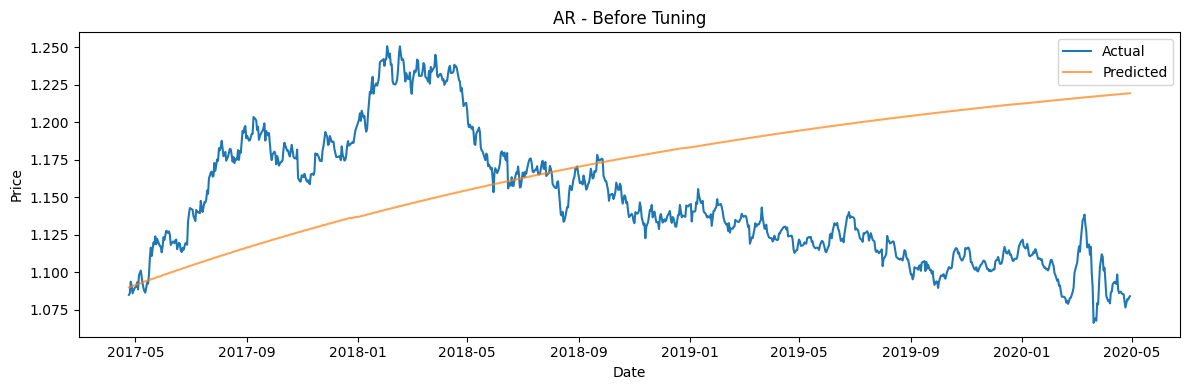

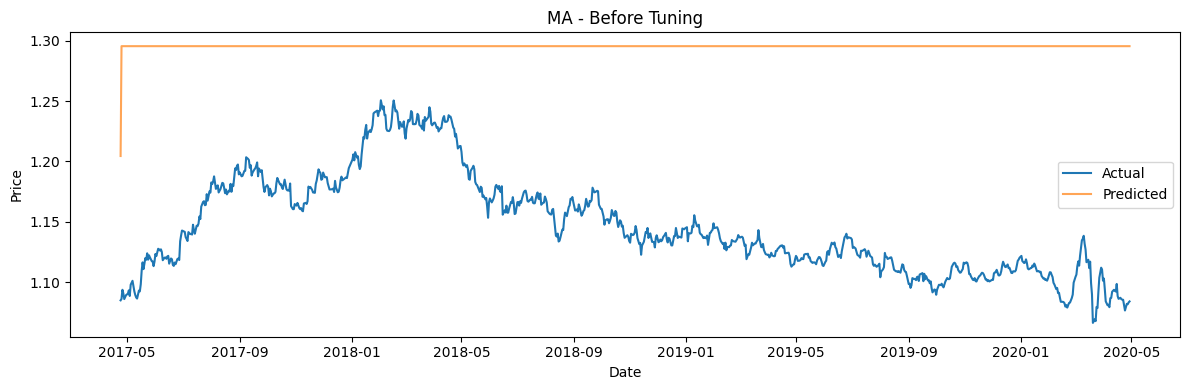

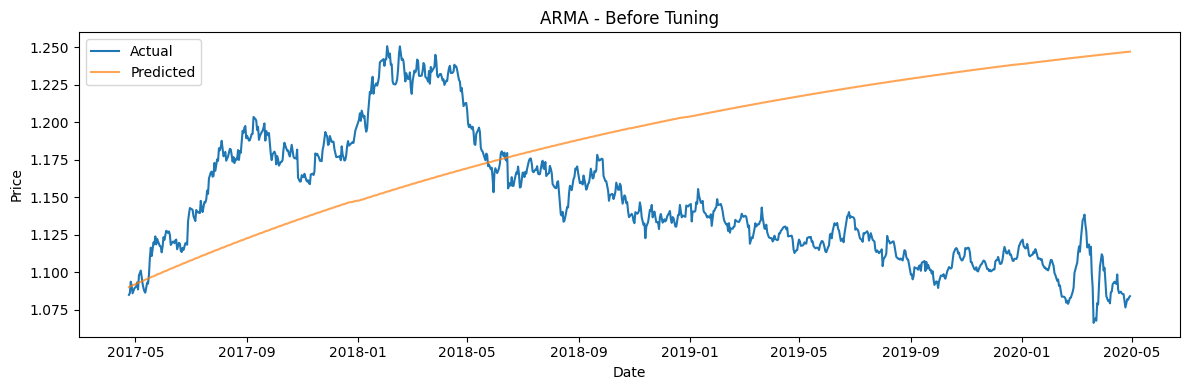

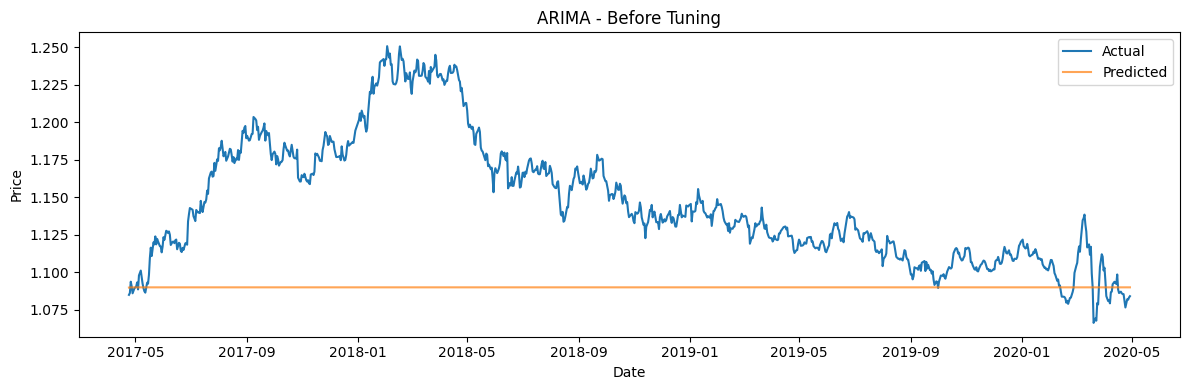

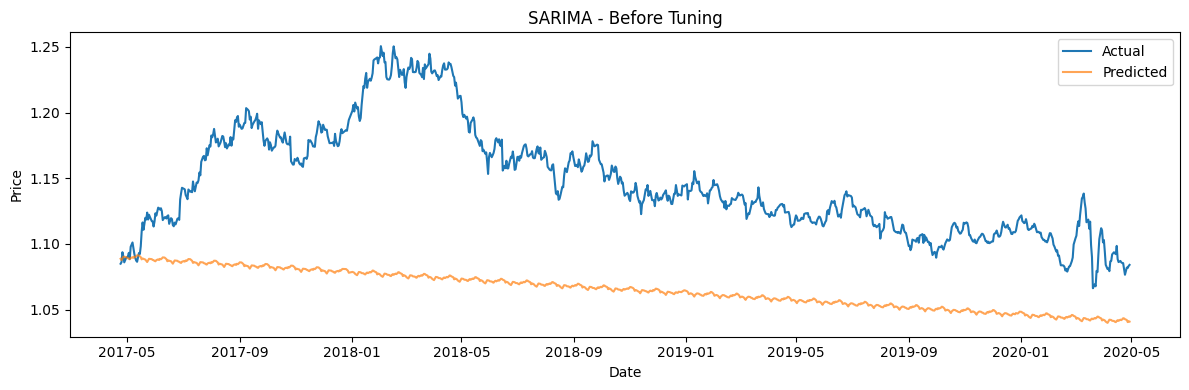

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


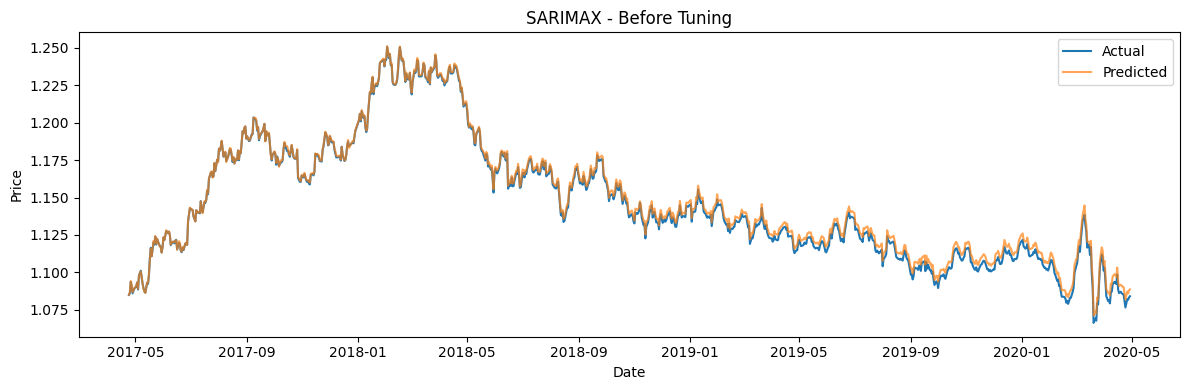

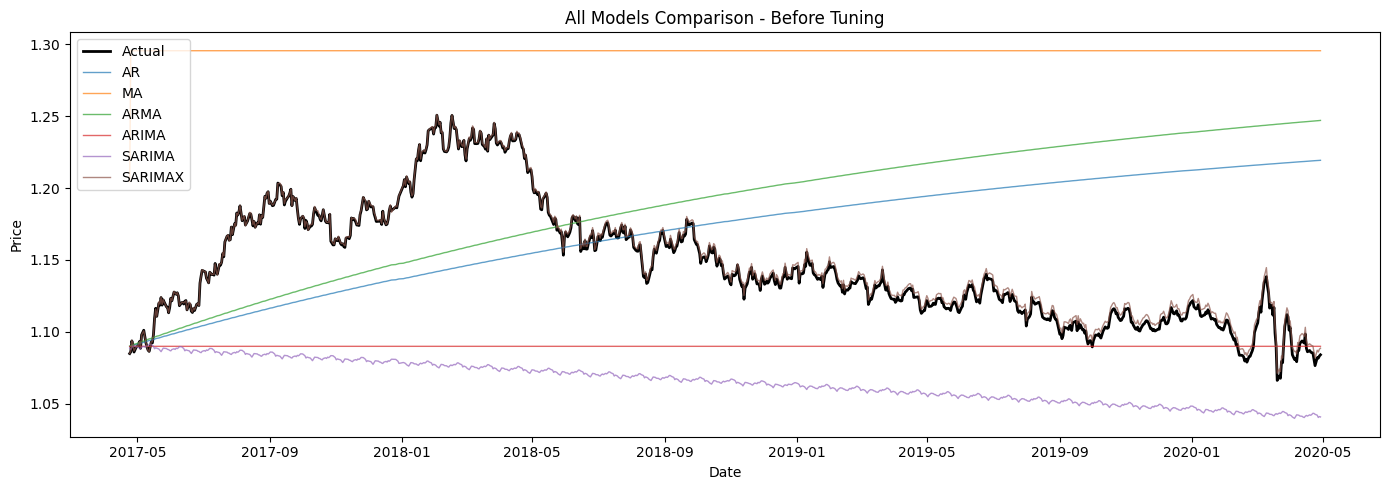


Baseline RMSE Dictionary:
{'AR': 0.07238434969351024, 'MA': 0.15445175858662566, 'ARMA': 0.08554910661409021, 'ARIMA': 0.07000539405790264, 'SARIMA': 0.08792856387798849, 'SARIMAX': 0.0027979687670410445}

AR: 0.072384
MA: 0.154452
ARMA: 0.085549
ARIMA: 0.070005
SARIMA: 0.087929
SARIMAX: 0.002798


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import sqrt

# Assuming all models are already fitted from previous steps
# Models: ar_fitted, ma_fitted, arma_fitted, arima_fitted, sarima_fitted, sarimax_fitted
# Data: train, test, data

# Prepare test indices for x-axis
test_index = data.index[train_size:]

# Calculate predictions for each model if not already done
ar_pred = ar_fitted.get_prediction(start=len(train), end=len(data)-1).predicted_mean
ma_pred = ma_fitted.get_forecast(steps=len(test)).predicted_mean
arma_pred = arma_fitted.get_forecast(steps=len(test)).predicted_mean
arima_pred = arima_fitted.get_forecast(steps=len(test)).predicted_mean
sarima_pred = sarima_fitted.get_forecast(steps=len(test)).predicted_mean

# Calculate RMSE for each model
def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    return rmse

ar_rmse = calculate_rmse(test, ar_pred)
ma_rmse = calculate_rmse(test, ma_pred)
arma_rmse = calculate_rmse(test, arma_pred)
arima_rmse = calculate_rmse(test, arima_pred)
sarima_rmse = calculate_rmse(test, sarima_pred)

# Dictionary to store RMSE values
baseline_rmse = {
    "AR": ar_rmse,
    "MA": ma_rmse,
    "ARMA": arma_rmse,
    "ARIMA": arima_rmse,
    "SARIMA": sarima_rmse
}

# Plot 1: AR - Before Tuning
plt.figure(figsize=(12, 4))
plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
plt.plot(test_index, ar_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('AR - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: MA - Before Tuning
plt.figure(figsize=(12, 4))
plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
plt.plot(test_index, ma_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('MA - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: ARMA - Before Tuning
plt.figure(figsize=(12, 4))
plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
plt.plot(test_index, arma_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('ARMA - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 4: ARIMA - Before Tuning
plt.figure(figsize=(12, 4))
plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
plt.plot(test_index, arima_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('ARIMA - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 5: SARIMA - Before Tuning
plt.figure(figsize=(12, 4))
plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
plt.plot(test_index, sarima_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('SARIMA - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 6: SARIMAX - Before Tuning (if available)
if exog_available:
    sarimax_pred = sarimax_fitted.get_forecast(steps=len(test), exog=exog_test).predicted_mean
    sarimax_rmse = calculate_rmse(test, sarimax_pred)
    baseline_rmse["SARIMAX"] = sarimax_rmse

    plt.figure(figsize=(12, 4))
    plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
    plt.plot(test_index, sarimax_pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
    plt.title('SARIMAX - Before Tuning')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Combined Plot: All models comparison
plt.figure(figsize=(14, 5))
plt.plot(test_index, test.values, label='Actual', linewidth=2, color='black')
plt.plot(test_index, ar_pred.values, label='AR', linewidth=1, alpha=0.7)
plt.plot(test_index, ma_pred.values, label='MA', linewidth=1, alpha=0.7)
plt.plot(test_index, arma_pred.values, label='ARMA', linewidth=1, alpha=0.7)
plt.plot(test_index, arima_pred.values, label='ARIMA', linewidth=1, alpha=0.7)
plt.plot(test_index, sarima_pred.values, label='SARIMA', linewidth=1, alpha=0.7)
if exog_available:
    plt.plot(test_index, sarimax_pred.values, label='SARIMAX', linewidth=1, alpha=0.7)
plt.title('All Models Comparison - Before Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Print RMSE dictionary
print("\n" + "="*50)
print("Baseline RMSE Dictionary:")
print("="*50)
print(baseline_rmse)
print("\n" + "="*50)
for model, rmse in baseline_rmse.items():
    print(f"{model}: {rmse:.6f}")

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00


[I 2026-04-13 18:49:27,102] A new study created in memory with name: no-name-5036884f-54fd-4579-800c-eee77bb4d360
[I 2026-04-13 18:49:27,149] Trial 0 finished with value: 0.07238434969351024 and parameters: {'p': 1}. Best is trial 0 with value: 0.07238434969351024.
[I 2026-04-13 18:49:27,227] Trial 1 finished with value: 0.06789848779804367 and parameters: {'p': 5}. Best is trial 1 with value: 0.06789848779804367.
[I 2026-04-13 18:49:27,285] Trial 2 finished with value: 0.07202442512935829 and parameters: {'p': 3}. Best is trial 1 with value: 0.06789848779804367.
[I 2026-04-13 18:49:27,354] Trial 3 finished with value: 0.06789848779804367 and parameters: {'p': 5}. Best is trial 1 with value: 0.06789848779804367.
[I 2026-04-13 18:49:27,420] Trial 4 finished with value: 0.07024436572472041 and parameters: {'p': 4}. Best is trial 1 with value: 0.06789848779804367.
[I 2026-04-13 18:49:27,450] Trial 5 finished with value: 0.07321088161933899 and parameters: {'p': 2}. Best is trial 1 with va

AR - Best p: 5, Best RMSE: 0.067898


[I 2026-04-13 18:49:42,593] Trial 0 finished with value: 0.15418336643557068 and parameters: {'q': 5}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:49:48,322] Trial 1 finished with value: 0.15432421280053127 and parameters: {'q': 2}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:50:00,624] Trial 2 finished with value: 0.15418336643557068 and parameters: {'q': 5}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:50:05,693] Trial 3 finished with value: 0.1542742158202899 and parameters: {'q': 3}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:50:09,841] Trial 4 finished with value: 0.15432421280053127 and parameters: {'q': 2}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:50:15,066] Trial 5 finished with value: 0.15418336643557068 and parameters: {'q': 5}. Best is trial 0 with value: 0.15418336643557068.
[I 2026-04-13 18:50:26,049] Trial 6 finished with value: 0.1526189885007961 and parameter

MA - Best q: 4, Best RMSE: 0.152619


[I 2026-04-13 18:51:55,558] A new study created in memory with name: no-name-5845a2bd-fc84-4dd3-b9b2-bb6c1cd5e04d
[I 2026-04-13 18:52:02,021] Trial 0 finished with value: 0.1542742158202899 and parameters: {'p': 0, 'q': 3}. Best is trial 0 with value: 0.1542742158202899.
[I 2026-04-13 18:52:03,251] Trial 1 finished with value: 0.0855659305706271 and parameters: {'p': 2, 'q': 0}. Best is trial 1 with value: 0.0855659305706271.
[I 2026-04-13 18:52:17,635] Trial 2 finished with value: 0.0645237077896665 and parameters: {'p': 5, 'q': 3}. Best is trial 2 with value: 0.0645237077896665.
[I 2026-04-13 18:52:19,345] Trial 3 finished with value: 0.08554910661409021 and parameters: {'p': 1, 'q': 1}. Best is trial 2 with value: 0.0645237077896665.
[I 2026-04-13 18:52:20,904] Trial 4 finished with value: 0.08478034380139446 and parameters: {'p': 3, 'q': 1}. Best is trial 2 with value: 0.0645237077896665.
[I 2026-04-13 18:52:20,907] Trial 5 finished with value: inf and parameters: {'p': 0, 'q': 0}.

ARMA - Best p: 5, q: 3, Best RMSE: 0.064524


[I 2026-04-13 18:54:47,790] A new study created in memory with name: no-name-0161348e-4b62-4515-b9dd-6b045310db42
[I 2026-04-13 18:54:48,589] Trial 0 finished with value: 0.07051848699342536 and parameters: {'p': 0, 'd': 1, 'q': 3}. Best is trial 0 with value: 0.07051848699342536.
[I 2026-04-13 18:54:51,217] Trial 1 finished with value: 0.07067742000566934 and parameters: {'p': 3, 'd': 1, 'q': 5}. Best is trial 0 with value: 0.07051848699342536.
[I 2026-04-13 18:54:53,882] Trial 2 finished with value: 0.07051860399615044 and parameters: {'p': 2, 'd': 1, 'q': 3}. Best is trial 0 with value: 0.07051848699342536.
[I 2026-04-13 18:54:54,413] Trial 3 finished with value: 0.07025162916475951 and parameters: {'p': 2, 'd': 1, 'q': 2}. Best is trial 3 with value: 0.07025162916475951.
[I 2026-04-13 18:54:55,740] Trial 4 finished with value: 0.0855659305706271 and parameters: {'p': 2, 'd': 0, 'q': 0}. Best is trial 3 with value: 0.07025162916475951.
[I 2026-04-13 18:54:58,873] Trial 5 finished wi

ARIMA - Best p: 1, d: 1, q: 1, Best RMSE: 0.070005


[I 2026-04-13 18:55:29,880] A new study created in memory with name: no-name-c1c57c0d-27ea-4b4e-8827-548d19316c31
[I 2026-04-13 18:55:32,440] Trial 0 finished with value: 0.07038878582013983 and parameters: {'p': 2, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q': 1}. Best is trial 0 with value: 0.07038878582013983.
[I 2026-04-13 18:55:35,315] Trial 1 finished with value: 0.07035979949495903 and parameters: {'p': 2, 'd': 0, 'q': 1, 'P': 0, 'D': 0, 'Q': 0}. Best is trial 1 with value: 0.07035979949495903.
[I 2026-04-13 18:55:42,129] Trial 2 finished with value: 0.10575045455028223 and parameters: {'p': 2, 'd': 0, 'q': 3, 'P': 1, 'D': 0, 'Q': 0}. Best is trial 1 with value: 0.07035979949495903.
[I 2026-04-13 18:56:36,062] Trial 3 finished with value: 0.08778981888514378 and parameters: {'p': 2, 'd': 1, 'q': 0, 'P': 0, 'D': 1, 'Q': 1}. Best is trial 1 with value: 0.07035979949495903.
[I 2026-04-13 18:59:08,579] Trial 4 finished with value: 0.219959885600589 and parameters: {'p': 3, 'd': 2, 'q': 1, 'P

SARIMA - Best (p,d,q): (2,1,3), (P,D,Q): (2,0,1), Best RMSE: 0.070140

Tuned RMSE Dictionary:
AR: 0.067898
MA: 0.152619
ARMA: 0.064524
ARIMA: 0.070005
SARIMA: 0.070140


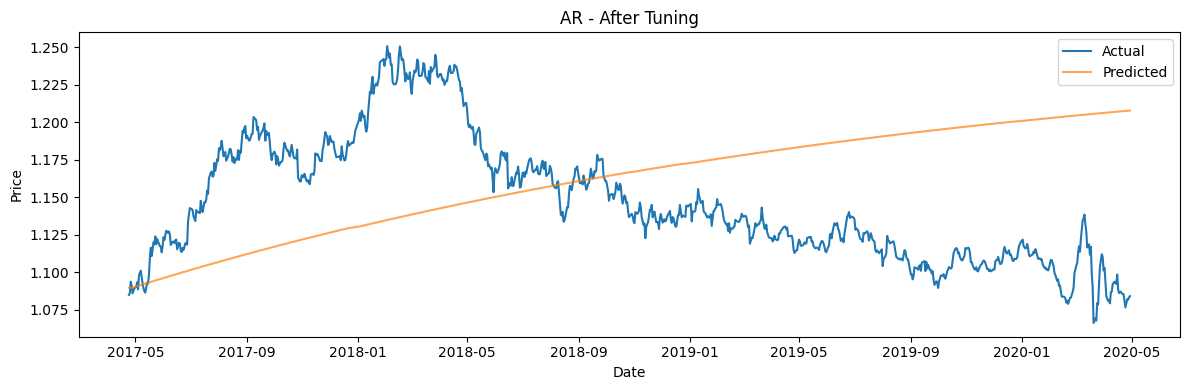

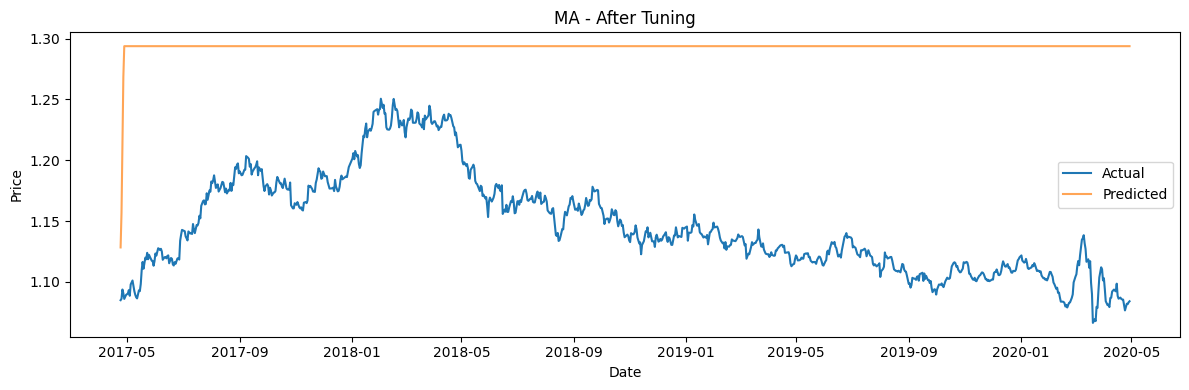

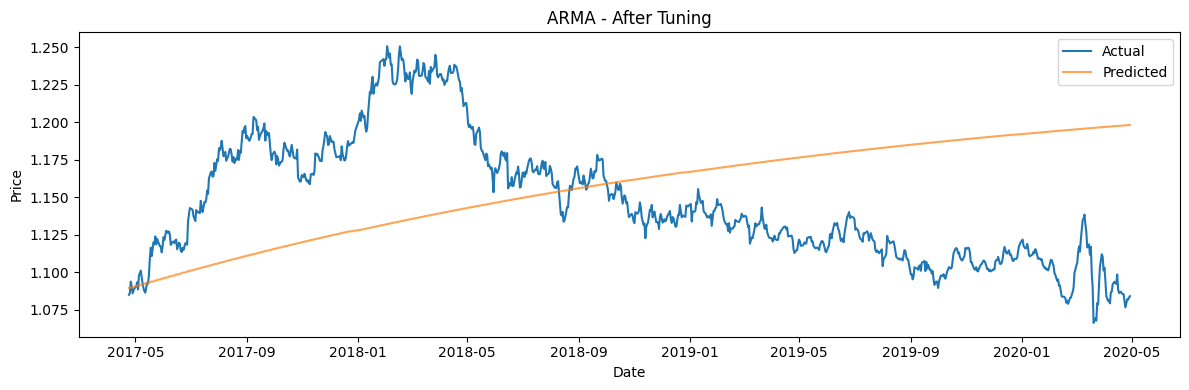

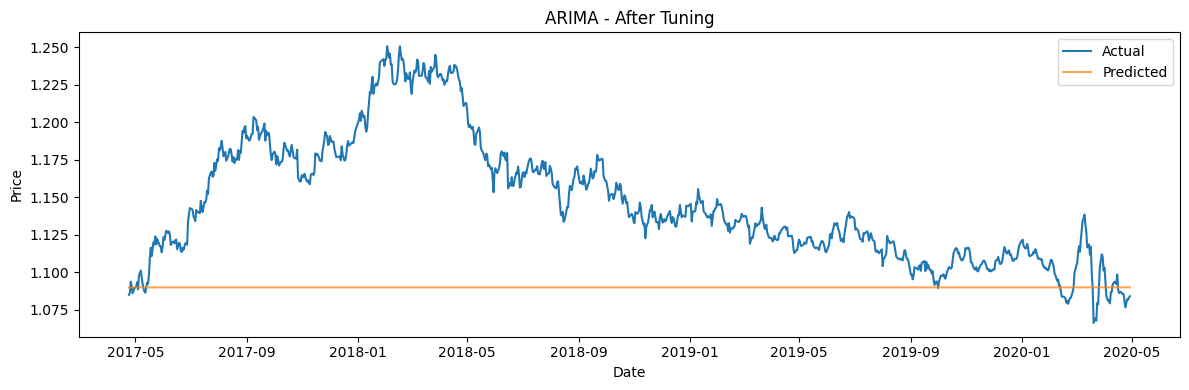

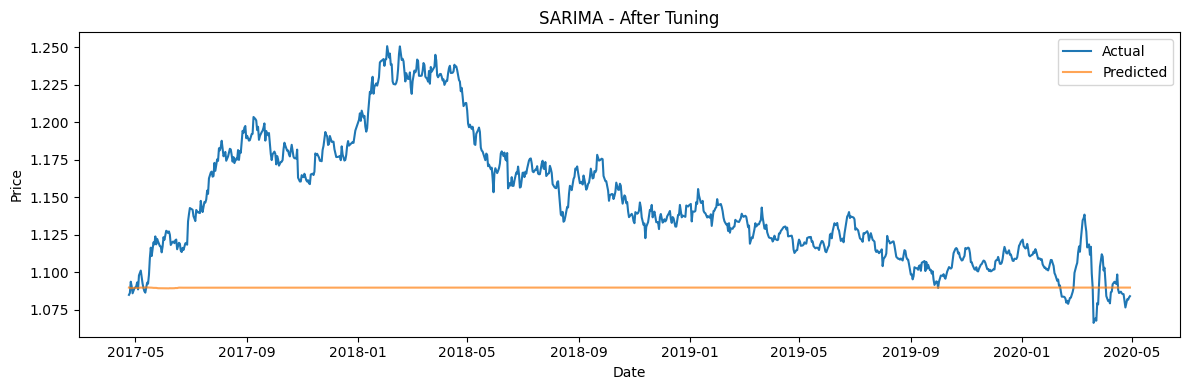

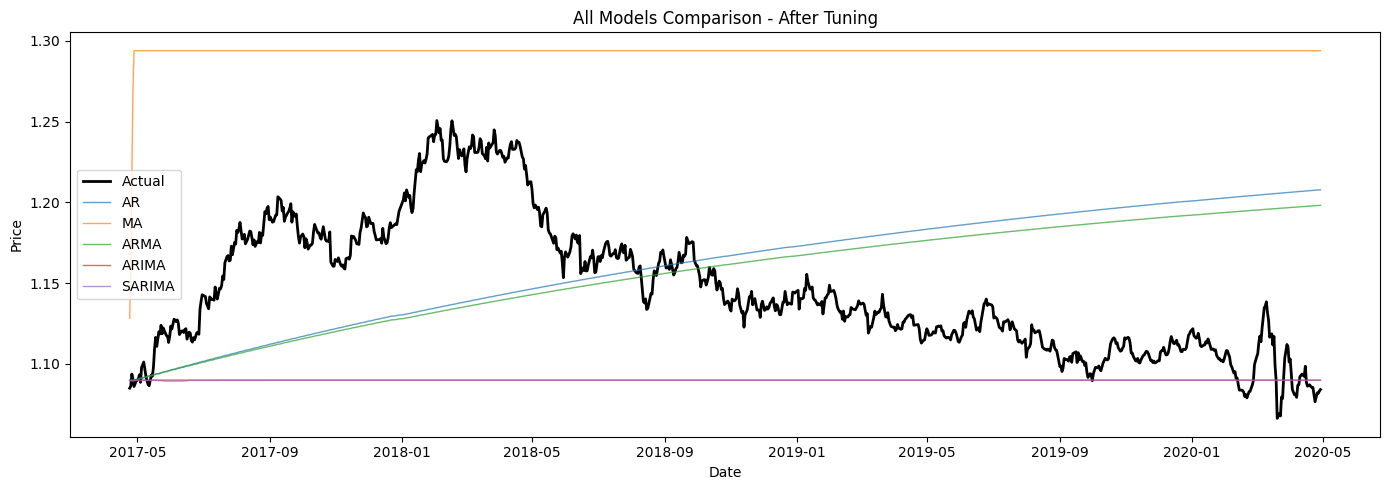

In [ ]:
import optuna
from optuna.pruners import MedianPruner
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare data
data = df['BC'].dropna()
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]
test_index = data.index[train_size:]

def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return sqrt(mse)

# ===== AR TUNING =====
def objective_ar(trial):
    p = trial.suggest_int('p', 0, 5)
    if p == 0:
        return float('inf')
    try:
        model = AutoReg(train, lags=p)
        fitted = model.fit()
        pred = fitted.get_prediction(start=len(train), end=len(data)-1).predicted_mean
        rmse = calculate_rmse(test, pred)
        return rmse
    except:
        return float('inf')

study_ar = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_ar.optimize(objective_ar, n_trials=20, show_progress_bar=False)
best_p_ar = study_ar.best_params['p']
print(f"AR - Best p: {best_p_ar}, Best RMSE: {study_ar.best_value:.6f}")

ar_model_opt = AutoReg(train, lags=best_p_ar)
ar_fitted_opt = ar_model_opt.fit()
predictions_ar_opt = ar_fitted_opt.get_prediction(start=len(train), end=len(data)-1).predicted_mean
rmse_ar_opt = calculate_rmse(test, predictions_ar_opt)

# ===== MA TUNING =====
def objective_ma(trial):
    q = trial.suggest_int('q', 0, 5)
    if q == 0:
        return float('inf')
    try:
        model = ARIMA(train, order=(0, 0, q))
        fitted = model.fit()
        pred = fitted.get_forecast(steps=len(test)).predicted_mean
        rmse = calculate_rmse(test, pred)
        return rmse
    except:
        return float('inf')

study_ma = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_ma.optimize(objective_ma, n_trials=20, show_progress_bar=False)
best_q_ma = study_ma.best_params['q']
print(f"MA - Best q: {best_q_ma}, Best RMSE: {study_ma.best_value:.6f}")

ma_model_opt = ARIMA(train, order=(0, 0, best_q_ma))
ma_fitted_opt = ma_model_opt.fit()
predictions_ma_opt = ma_fitted_opt.get_forecast(steps=len(test)).predicted_mean
rmse_ma_opt = calculate_rmse(test, predictions_ma_opt)

# ===== ARMA TUNING =====
def objective_arma(trial):
    p = trial.suggest_int('p', 0, 5)
    q = trial.suggest_int('q', 0, 5)
    if p == 0 and q == 0:
        return float('inf')
    try:
        model = ARIMA(train, order=(p, 0, q))
        fitted = model.fit()
        pred = fitted.get_forecast(steps=len(test)).predicted_mean
        rmse = calculate_rmse(test, pred)
        return rmse
    except:
        return float('inf')

study_arma = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_arma.optimize(objective_arma, n_trials=20, show_progress_bar=False)
best_p_arma = study_arma.best_params['p']
best_q_arma = study_arma.best_params['q']
print(f"ARMA - Best p: {best_p_arma}, q: {best_q_arma}, Best RMSE: {study_arma.best_value:.6f}")

arma_model_opt = ARIMA(train, order=(best_p_arma, 0, best_q_arma))
arma_fitted_opt = arma_model_opt.fit()
predictions_arma_opt = arma_fitted_opt.get_forecast(steps=len(test)).predicted_mean
rmse_arma_opt = calculate_rmse(test, predictions_arma_opt)

# ===== ARIMA TUNING =====
def objective_arima(trial):
    p = trial.suggest_int('p', 0, 5)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 5)
    if p == 0 and d == 0 and q == 0:
        return float('inf')
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        pred = fitted.get_forecast(steps=len(test)).predicted_mean
        rmse = calculate_rmse(test, pred)
        return rmse
    except:
        return float('inf')

study_arima = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_arima.optimize(objective_arima, n_trials=20, show_progress_bar=False)
best_p_arima = study_arima.best_params['p']
best_d_arima = study_arima.best_params['d']
best_q_arima = study_arima.best_params['q']
print(f"ARIMA - Best p: {best_p_arima}, d: {best_d_arima}, q: {best_q_arima}, Best RMSE: {study_arima.best_value:.6f}")

arima_model_opt = ARIMA(train, order=(best_p_arima, best_d_arima, best_q_arima))
arima_fitted_opt = arima_model_opt.fit()
predictions_arima_opt = arima_fitted_opt.get_forecast(steps=len(test)).predicted_mean
rmse_arima_opt = calculate_rmse(test, predictions_arima_opt)

# ===== SARIMA TUNING =====
def objective_sarima(trial):
    p = trial.suggest_int('p', 0, 3)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 3)
    P = trial.suggest_int('P', 0, 2)
    D = trial.suggest_int('D', 0, 1)
    Q = trial.suggest_int('Q', 0, 2)
    if p == 0 and d == 0 and q == 0 and P == 0 and D == 0 and Q == 0:
        return float('inf')
    try:
        model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, 24))
        fitted = model.fit(disp=False)
        pred = fitted.get_forecast(steps=len(test)).predicted_mean
        rmse = calculate_rmse(test, pred)
        return rmse
    except:
        return float('inf')

study_sarima = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_sarima.optimize(objective_sarima, n_trials=20, show_progress_bar=False)
best_p_sarima = study_sarima.best_params['p']
best_d_sarima = study_sarima.best_params['d']
best_q_sarima = study_sarima.best_params['q']
best_P_sarima = study_sarima.best_params['P']
best_D_sarima = study_sarima.best_params['D']
best_Q_sarima = study_sarima.best_params['Q']
print(f"SARIMA - Best (p,d,q): ({best_p_sarima},{best_d_sarima},{best_q_sarima}), (P,D,Q): ({best_P_sarima},{best_D_sarima},{best_Q_sarima}), Best RMSE: {study_sarima.best_value:.6f}")

sarima_model_opt = SARIMAX(train, order=(best_p_sarima, best_d_sarima, best_q_sarima),
                           seasonal_order=(best_P_sarima, best_D_sarima, best_Q_sarima, 24))
sarima_fitted_opt = sarima_model_opt.fit(disp=False)
predictions_sarima_opt = sarima_fitted_opt.get_forecast(steps=len(test)).predicted_mean
rmse_sarima_opt = calculate_rmse(test, predictions_sarima_opt)

# Store tuned RMSE values
tuned_rmse = {
    "AR": rmse_ar_opt,
    "MA": rmse_ma_opt,
    "ARMA": rmse_arma_opt,
    "ARIMA": rmse_arima_opt,
    "SARIMA": rmse_sarima_opt
}

print("\n" + "="*50)
print("Tuned RMSE Dictionary:")
print("="*50)
for model, rmse in tuned_rmse.items():
    print(f"{model}: {rmse:.6f}")

# Individual plots for optimized models
models_data = [
    (predictions_ar_opt, "AR - After Tuning"),
    (predictions_ma_opt, "MA - After Tuning"),
    (predictions_arma_opt, "ARMA - After Tuning"),
    (predictions_arima_opt, "ARIMA - After Tuning"),
    (predictions_sarima_opt, "SARIMA - After Tuning")
]

for pred, title in models_data:
    plt.figure(figsize=(12, 4))
    plt.plot(test_index, test.values, label='Actual', linewidth=1.5)
    plt.plot(test_index, pred.values, label='Predicted', linewidth=1.5, alpha=0.7)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Combined plot: All optimized models
plt.figure(figsize=(14, 5))
plt.plot(test_index, test.values, label='Actual', linewidth=2, color='black')
plt.plot(test_index, predictions_ar_opt.values, label='AR', linewidth=1, alpha=0.7)
plt.plot(test_index, predictions_ma_opt.values, label='MA', linewidth=1, alpha=0.7)
plt.plot(test_index, predictions_arma_opt.values, label='ARMA', linewidth=1, alpha=0.7)
plt.plot(test_index, predictions_arima_opt.values, label='ARIMA', linewidth=1, alpha=0.7)
plt.plot(test_index, predictions_sarima_opt.values, label='SARIMA', linewidth=1, alpha=0.7)
plt.title('All Models Comparison - After Tuning')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

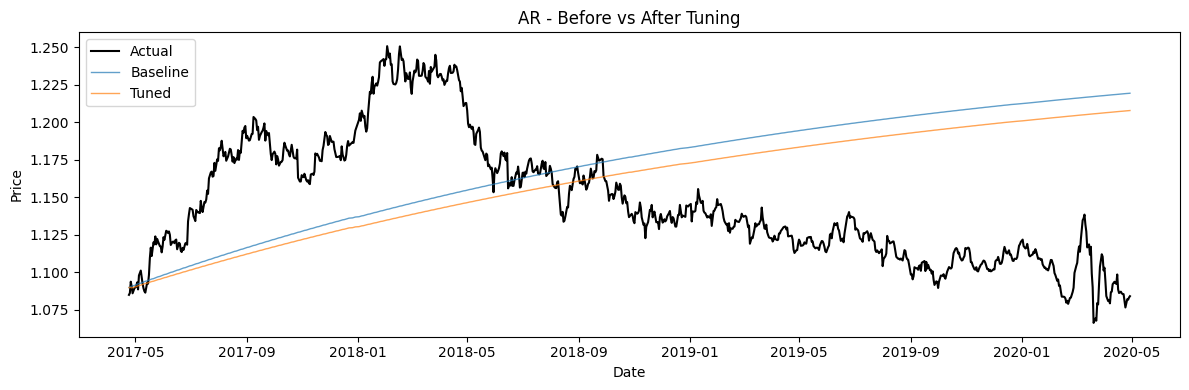

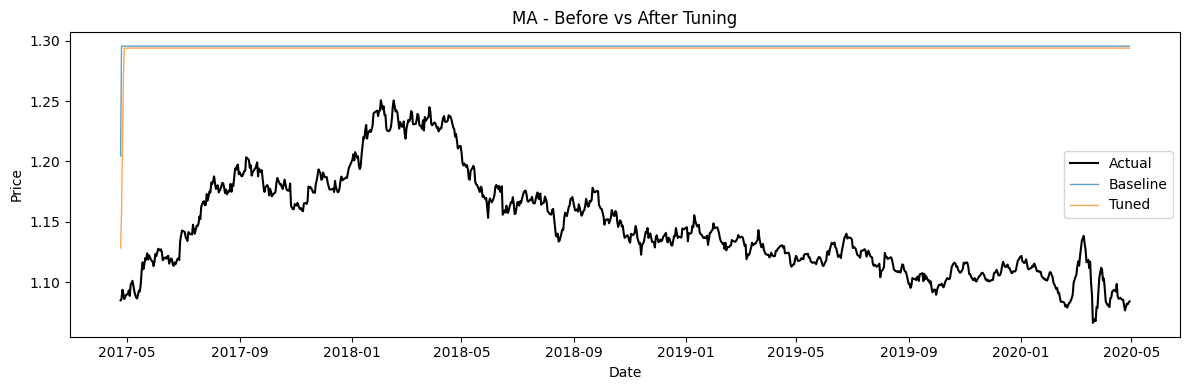

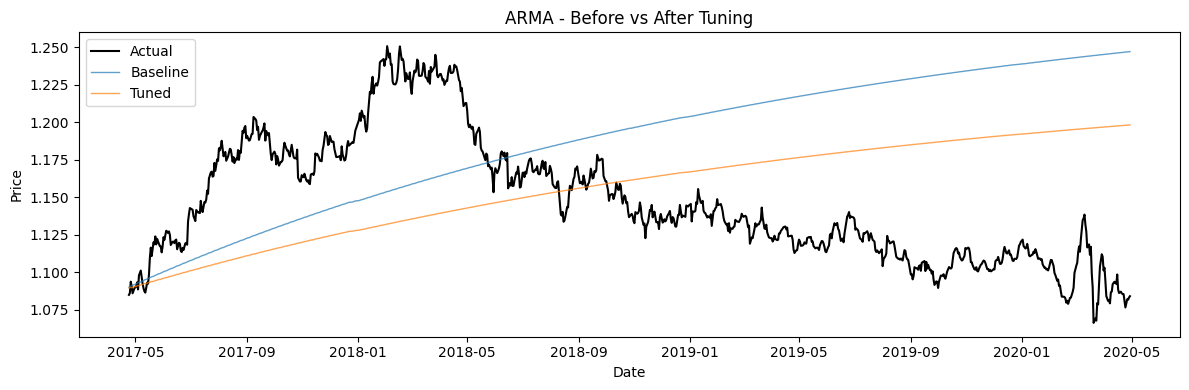

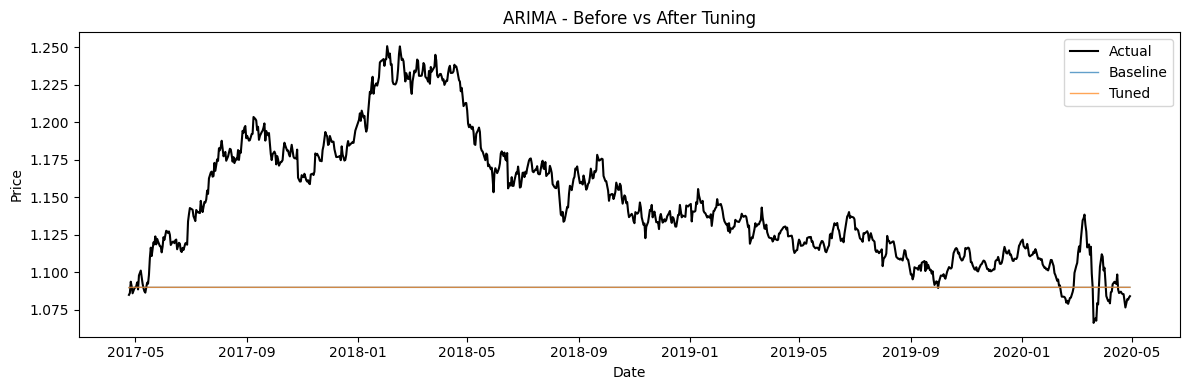

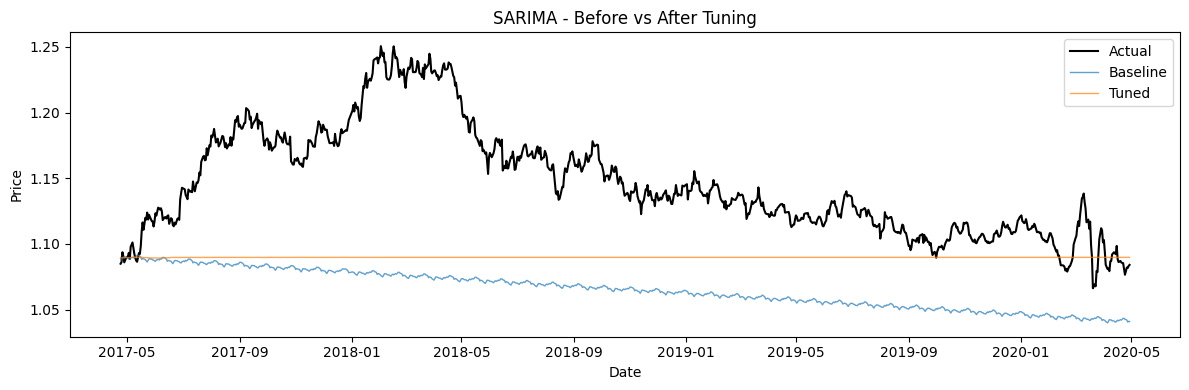


BEST MODELS:
Best Baseline Model: SARIMAX (RMSE: 0.002798)
Best Tuned Model: ARMA (RMSE: 0.064524)


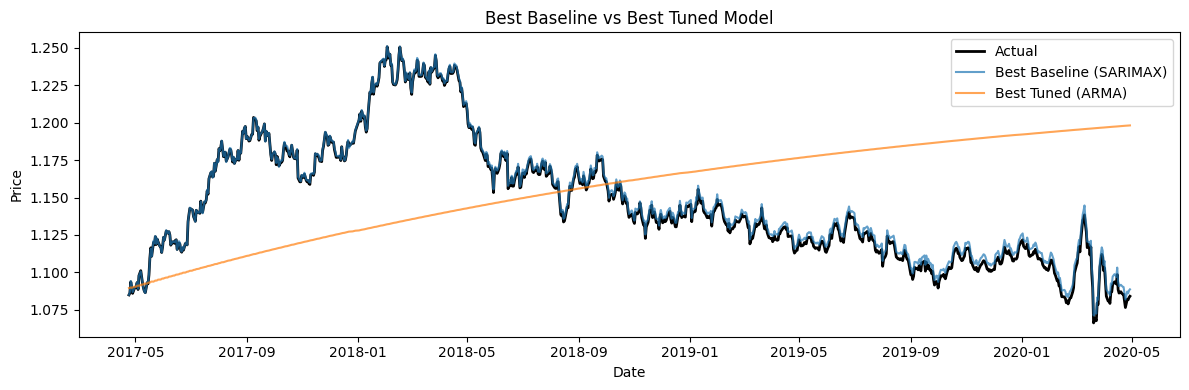

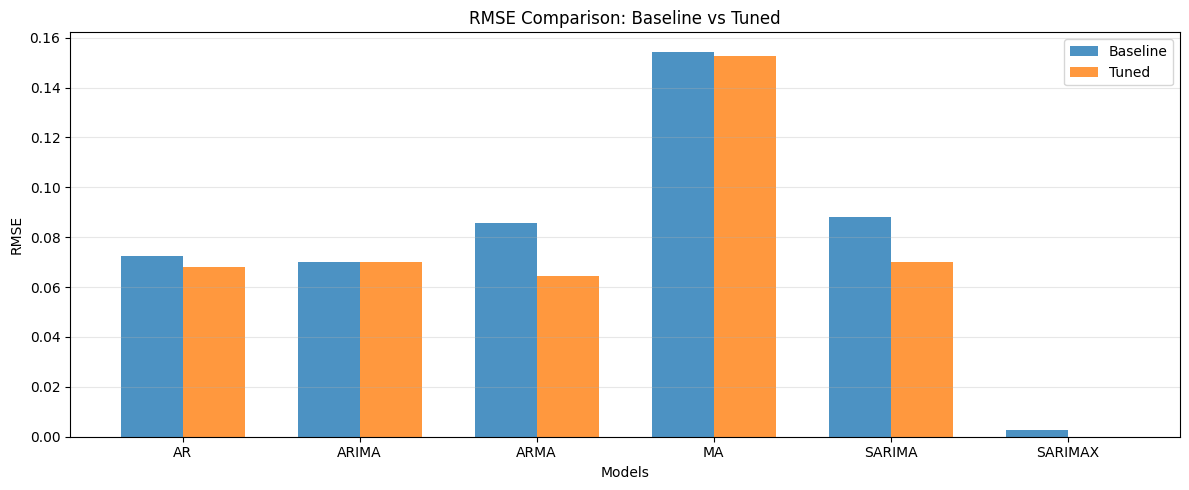


IMPROVEMENT ANALYSIS:
AR:
  Baseline RMSE: 0.072384
  Tuned RMSE:    0.067898
  Improvement:   6.20%

MA:
  Baseline RMSE: 0.154452
  Tuned RMSE:    0.152619
  Improvement:   1.19%

ARMA:
  Baseline RMSE: 0.085549
  Tuned RMSE:    0.064524
  Improvement:   24.58%

ARIMA:
  Baseline RMSE: 0.070005
  Tuned RMSE:    0.070005
  Improvement:   0.00%

SARIMA:
  Baseline RMSE: 0.087929
  Tuned RMSE:    0.070140
  Improvement:   20.23%

SUMMARY:
Average Baseline RMSE: 0.078853
Average Tuned RMSE:    0.085037
Overall Improvement:   -7.84%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
y_test = test
test_index = data.index[train_size:]

# Baseline predictions (from previous code)
baseline_predictions = {
    "AR": ar_pred,
    "MA": ma_pred,
    "ARMA": arma_pred,
    "ARIMA": arima_pred,
    "SARIMA": sarima_pred
}

# Conditionally add SARIMAX prediction if available
if 'SARIMAX' in baseline_rmse and 'sarimax_pred' in locals():
    baseline_predictions["SARIMAX"] = sarimax_pred

# Tuned predictions (from previous code)
tuned_predictions = {
    "AR": predictions_ar_opt,
    "MA": predictions_ma_opt,
    "ARMA": predictions_arma_opt,
    "ARIMA": predictions_arima_opt,
    "SARIMA": predictions_sarima_opt
}

# ===== TASK 1: Individual Before vs After Plots =====
models = ["AR", "MA", "ARMA", "ARIMA", "SARIMA"]

for model in models:
    plt.figure(figsize=(12, 4))
    plt.plot(test_index, y_test.values, label='Actual', linewidth=1.5, color='black')
    plt.plot(test_index, baseline_predictions[model].values, label='Baseline', linewidth=1, alpha=0.7)
    plt.plot(test_index, tuned_predictions[model].values, label='Tuned', linewidth=1, alpha=0.7)
    plt.title(f'{model} - Before vs After Tuning')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== TASK 2: Find Best Models =====
best_baseline_model = min(baseline_rmse, key=baseline_rmse.get)
best_tuned_model = min(tuned_rmse, key=tuned_rmse.get)

print("\n" + "="*60)
print("BEST MODELS:")
print("="*60)
print(f"Best Baseline Model: {best_baseline_model} (RMSE: {baseline_rmse[best_baseline_model]:.6f})")
print(f"Best Tuned Model: {best_tuned_model} (RMSE: {tuned_rmse[best_tuned_model]:.6f})")

# ===== TASK 3: Combined Plot - Best Baseline vs Best Tuned =====
plt.figure(figsize=(12, 4))
plt.plot(test_index, y_test.values, label='Actual', linewidth=2, color='black')
plt.plot(test_index, baseline_predictions[best_baseline_model].values,
         label=f'Best Baseline ({best_baseline_model})', linewidth=1.5, alpha=0.7)
plt.plot(test_index, tuned_predictions[best_tuned_model].values,
         label=f'Best Tuned ({best_tuned_model})', linewidth=1.5, alpha=0.7)
plt.title('Best Baseline vs Best Tuned Model')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# ===== TASK 4: RMSE Comparison Bar Chart =====
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(models))
width = 0.35

baseline_values = [baseline_rmse[model] for model in models if model in baseline_rmse] # Filter models that might not be in baseline_rmse
tuned_values = [tuned_rmse[model] for model in models if model in tuned_rmse] # Filter models that might not be in tuned_rmse

# Adjust x for models present in both if models list contains elements not in both rmse dicts
# For simplicity, ensure models list matches keys of rmse dicts or dynamically generate it
# Here, assuming `models` contains all keys present in `baseline_rmse` and `tuned_rmse` for this plot after previous error handling.

# Re-create models list if needed to ensure consistency for plotting
plot_models = sorted(list(set(baseline_rmse.keys()).union(tuned_rmse.keys())))
x = np.arange(len(plot_models))

bars1 = ax.bar(x - width/2, [baseline_rmse.get(model, 0) for model in plot_models], width, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, [tuned_rmse.get(model, 0) for model in plot_models], width, label='Tuned', alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison: Baseline vs Tuned')
ax.set_xticks(x)
ax.set_xticklabels(plot_models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ===== TASK 5: Print Improvement Statistics =====
print("\n" + "="*60)
print("IMPROVEMENT ANALYSIS:")
print("="*60)
for model in models:
    baseline = baseline_rmse.get(model)
    tuned = tuned_rmse.get(model)
    if baseline is not None and tuned is not None:
        improvement = ((baseline - tuned) / baseline) * 100
        print(f"{model}:")
        print(f"  Baseline RMSE: {baseline:.6f}")
        print(f"  Tuned RMSE:    {tuned:.6f}")
        print(f"  Improvement:   {improvement:.2f}%")
    elif baseline is not None:
        print(f"{model}: Only Baseline RMSE available: {baseline:.6f}")
    elif tuned is not None:
        print(f"{model}: Only Tuned RMSE available: {tuned:.6f}")
    else:
        print(f"{model}: No RMSE available")
    print()

# Summary statistics
print("="*60)
print("SUMMARY:")
print("="*60)
avg_baseline = np.mean([val for val in baseline_rmse.values() if val != 0]) # Exclude 0 if SARIMAX was not in models list
avg_tuned = np.mean([val for val in tuned_rmse.values() if val != 0])
overall_improvement = ((avg_baseline - avg_tuned) / avg_baseline) * 100

print(f"Average Baseline RMSE: {avg_baseline:.6f}")
print(f"Average Tuned RMSE:    {avg_tuned:.6f}")
print(f"Overall Improvement:   {overall_improvement:.2f}%")

X_train shape: (3732, 7), X_test shape: (934, 7)
y_train shape: (3732,), y_test shape: (934,)

Training Random Forest...
Random Forest RMSE: 0.003346
Training XGBoost...
XGBoost RMSE: 0.004204
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000856 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 3732, number of used features: 7
[LightGBM] [Info] Start training from score 1.295430
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

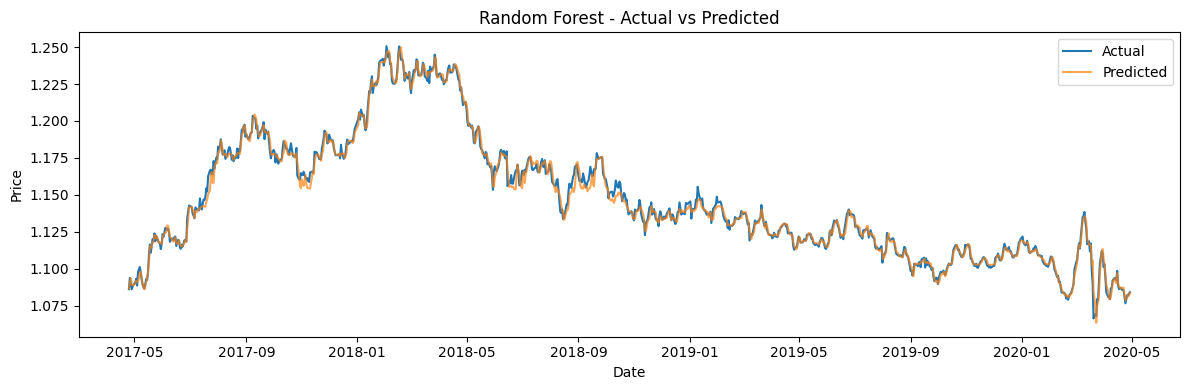

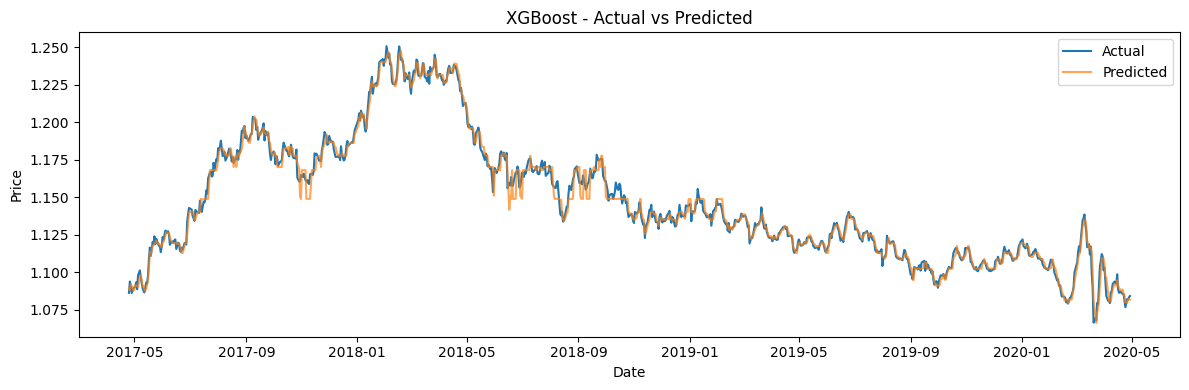

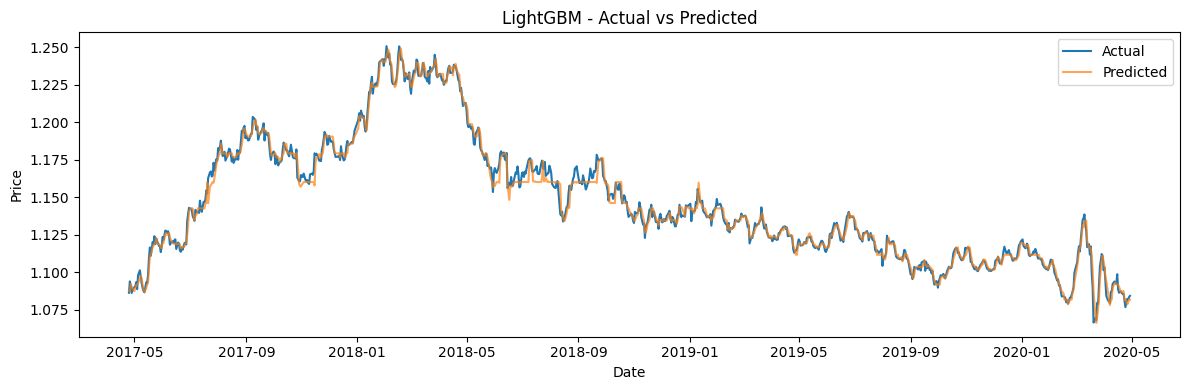

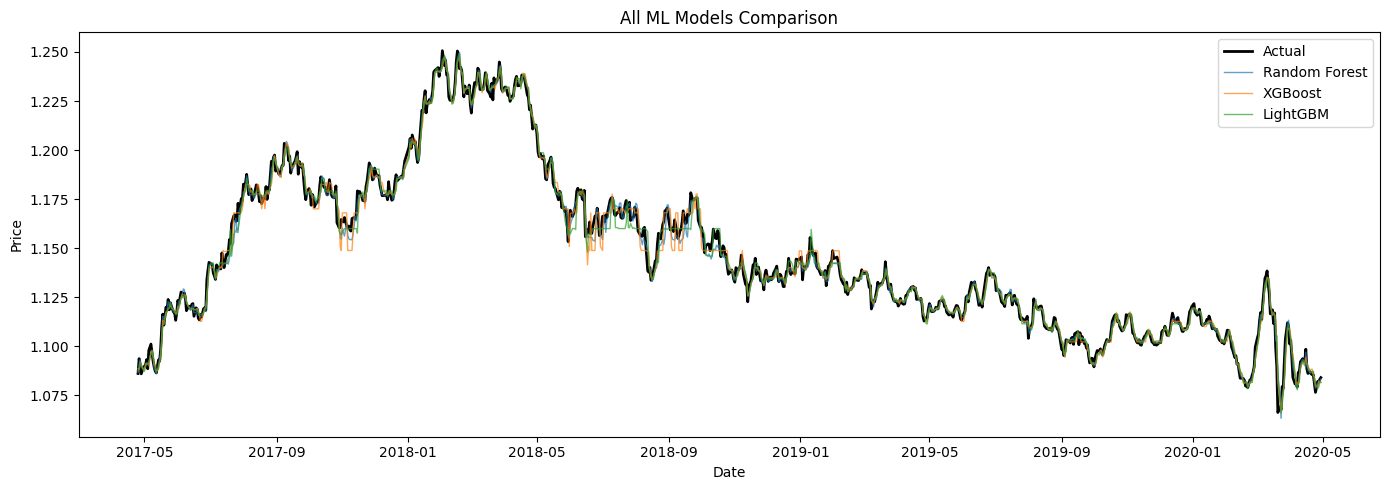

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Prepare data
data_ml = df['BC'].copy()

# ===== FEATURE ENGINEERING =====
# Create lag features
data_ml_df = pd.DataFrame({'price': data_ml})
data_ml_df['lag_1'] = data_ml_df['price'].shift(1)
data_ml_df['lag_2'] = data_ml_df['price'].shift(2)
data_ml_df['lag_3'] = data_ml_df['price'].shift(3)

# Create rolling statistics
data_ml_df['rolling_mean_3'] = data_ml_df['price'].rolling(window=3).mean()
data_ml_df['rolling_std_3'] = data_ml_df['price'].rolling(window=3).std()
data_ml_df['rolling_mean_7'] = data_ml_df['price'].rolling(window=7).mean()
data_ml_df['rolling_std_7'] = data_ml_df['price'].rolling(window=7).std()

# Drop NaN values
data_ml_df = data_ml_df.dropna()

# ===== PREPARE DATA =====
# Define features and target
X = data_ml_df[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7', 'rolling_std_7']]
y = data_ml_df['price']

# Time-based split (80-20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

test_index_ml = y_test.index

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}\n")

def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return sqrt(mse)

# ===== TRAIN ML MODELS =====

# 1. Random Forest Regressor
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
predictions_rf = rf_model.predict(X_test)
rmse_rf = calculate_rmse(y_test, predictions_rf)
print(f"Random Forest RMSE: {rmse_rf:.6f}")

# 2. XGBoost Regressor
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
predictions_xgb = xgb_model.predict(X_test)
rmse_xgb = calculate_rmse(y_test, predictions_xgb)
print(f"XGBoost RMSE: {rmse_xgb:.6f}")

# 3. LightGBM Regressor
print("Training LightGBM...")
lgbm_model = lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
lgbm_model.fit(X_train, y_train)
predictions_lgbm = lgbm_model.predict(X_test)
rmse_lgbm = calculate_rmse(y_test, predictions_lgbm)
print(f"LightGBM RMSE: {rmse_lgbm:.6f}")

# Store results
ml_rmse = {
    "RandomForest": rmse_rf,
    "XGBoost": rmse_xgb,
    "LightGBM": rmse_lgbm
}

print("\n" + "="*50)
print("ML Models RMSE:")
print("="*50)
for model, rmse in ml_rmse.items():
    print(f"{model}: {rmse:.6f}")

# ===== PLOTTING =====

# Plot 1: Random Forest
plt.figure(figsize=(12, 4))
plt.plot(test_index_ml, y_test.values, label='Actual', linewidth=1.5)
plt.plot(test_index_ml, predictions_rf, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('Random Forest - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: XGBoost
plt.figure(figsize=(12, 4))
plt.plot(test_index_ml, y_test.values, label='Actual', linewidth=1.5)
plt.plot(test_index_ml, predictions_xgb, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('XGBoost - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: LightGBM
plt.figure(figsize=(12, 4))
plt.plot(test_index_ml, y_test.values, label='Actual', linewidth=1.5)
plt.plot(test_index_ml, predictions_lgbm, label='Predicted', linewidth=1.5, alpha=0.7)
plt.title('LightGBM - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 4: Combined Plot - All ML Models
plt.figure(figsize=(14, 5))
plt.plot(test_index_ml, y_test.values, label='Actual', linewidth=2, color='black')
plt.plot(test_index_ml, predictions_rf, label='Random Forest', linewidth=1, alpha=0.7)
plt.plot(test_index_ml, predictions_xgb, label='XGBoost', linewidth=1, alpha=0.7)
plt.plot(test_index_ml, predictions_lgbm, label='LightGBM', linewidth=1, alpha=0.7)
plt.title('All ML Models Comparison')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from optuna.pruners import MedianPruner
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Data from previous step
# X_train, X_test, y_train, y_test, test_index_ml are already defined

def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return sqrt(mse)

# ===== RANDOM FOREST TUNING =====
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    try:
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                     random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rmse = calculate_rmse(y_test, pred)
        return rmse
    except:
        return float('inf')

study_rf = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=False)
best_n_est_rf = study_rf.best_params['n_estimators']
best_depth_rf = study_rf.best_params['max_depth']
print(f"RandomForest - Best n_estimators: {best_n_est_rf}, max_depth: {best_depth_rf}, Best RMSE: {study_rf.best_value:.6f}")

rf_model_opt = RandomForestRegressor(n_estimators=best_n_est_rf, max_depth=best_depth_rf,
                                     random_state=42, n_jobs=-1)
rf_model_opt.fit(X_train, y_train)
predictions_rf_opt = rf_model_opt.predict(X_test)
rmse_rf_opt = calculate_rmse(y_test, predictions_rf_opt)

# ===== XGBOOST TUNING =====
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)

    try:
        model = xgb.XGBRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                learning_rate=learning_rate, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rmse = calculate_rmse(y_test, pred)
        return rmse
    except:
        return float('inf')

study_xgb = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=False)
best_n_est_xgb = study_xgb.best_params['n_estimators']
best_depth_xgb = study_xgb.best_params['max_depth']
best_lr_xgb = study_xgb.best_params['learning_rate']
print(f"XGBoost - Best n_estimators: {best_n_est_xgb}, max_depth: {best_depth_xgb}, learning_rate: {best_lr_xgb:.4f}, Best RMSE: {study_xgb.best_value:.6f}")

xgb_model_opt = xgb.XGBRegressor(n_estimators=best_n_est_xgb, max_depth=best_depth_xgb,
                                 learning_rate=best_lr_xgb, random_state=42, n_jobs=-1)
xgb_model_opt.fit(X_train, y_train)
predictions_xgb_opt = xgb_model_opt.predict(X_test)
rmse_xgb_opt = calculate_rmse(y_test, predictions_xgb_opt)

# ===== LIGHTGBM TUNING =====
def objective_lgbm(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)

    try:
        model = lgb.LGBMRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                 learning_rate=learning_rate, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rmse = calculate_rmse(y_test, pred)
        return rmse
    except:
        return float('inf')

study_lgbm = optuna.create_study(direction='minimize', pruner=MedianPruner())
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=False)
best_n_est_lgbm = study_lgbm.best_params['n_estimators']
best_depth_lgbm = study_lgbm.best_params['max_depth']
best_lr_lgbm = study_lgbm.best_params['learning_rate']
print(f"LightGBM - Best n_estimators: {best_n_est_lgbm}, max_depth: {best_depth_lgbm}, learning_rate: {best_lr_lgbm:.4f}, Best RMSE: {study_lgbm.best_value:.6f}")

lgbm_model_opt = lgb.LGBMRegressor(n_estimators=best_n_est_lgbm, max_depth=best_depth_lgbm,
                                   learning_rate=best_lr_lgbm, random_state=42, n_jobs=-1)
lgbm_model_opt.fit(X_train, y_train)
predictions_lgbm_opt = lgbm_model_opt.predict(X_test)
rmse_lgbm_opt = calculate_rmse(y_test, predictions_lgbm_opt)

# Store tuned results
tuned_ml_rmse = {
    "RandomForest": rmse_rf_opt,
    "XGBoost": rmse_xgb_opt,
    "LightGBM": rmse_lgbm_opt
}

print("\n" + "="*50)
print("Tuned ML Models RMSE:")
print("="*50)
for model, rmse in tuned_ml_rmse.items():
    print(f"{model}: {rmse:.6f}")

[I 2026-04-13 19:30:21,560] A new study created in memory with name: no-name-fbb6f402-3dde-4424-9551-555b8e68b559
[I 2026-04-13 19:30:24,090] Trial 0 finished with value: 0.0032974087293116084 and parameters: {'n_estimators': 50, 'max_depth': 17}. Best is trial 0 with value: 0.0032974087293116084.
[I 2026-04-13 19:30:37,100] Trial 1 finished with value: 0.0033835948112809393 and parameters: {'n_estimators': 251, 'max_depth': 19}. Best is trial 0 with value: 0.0032974087293116084.
[I 2026-04-13 19:30:42,034] Trial 2 finished with value: 0.0033736487614465746 and parameters: {'n_estimators': 197, 'max_depth': 16}. Best is trial 0 with value: 0.0032974087293116084.
[I 2026-04-13 19:30:44,443] Trial 3 finished with value: 0.0035848779346745966 and parameters: {'n_estimators': 105, 'max_depth': 8}. Best is trial 0 with value: 0.0032974087293116084.
[I 2026-04-13 19:30:52,395] Trial 4 finished with value: 0.0033815096743764145 and parameters: {'n_estimators': 300, 'max_depth': 14}. Best is t

RandomForest - Best n_estimators: 52, max_depth: 20, Best RMSE: 0.003265


[I 2026-04-13 19:31:40,604] A new study created in memory with name: no-name-4df0c6f4-20bb-4608-bcc4-04e7f723cea7
[I 2026-04-13 19:31:40,938] Trial 0 finished with value: 0.004461117182073264 and parameters: {'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.0739351036138235}. Best is trial 0 with value: 0.004461117182073264.
[I 2026-04-13 19:31:41,411] Trial 1 finished with value: 0.0042997990503829435 and parameters: {'n_estimators': 286, 'max_depth': 5, 'learning_rate': 0.28236154519198403}. Best is trial 1 with value: 0.0042997990503829435.
[I 2026-04-13 19:31:41,910] Trial 2 finished with value: 0.005348815959101714 and parameters: {'n_estimators': 240, 'max_depth': 6, 'learning_rate': 0.015487771738015028}. Best is trial 1 with value: 0.0042997990503829435.
[I 2026-04-13 19:31:42,124] Trial 3 finished with value: 0.0041370562736572055 and parameters: {'n_estimators': 107, 'max_depth': 6, 'learning_rate': 0.06244254061125366}. Best is trial 3 with value: 0.004137056273657205

XGBoost - Best n_estimators: 127, max_depth: 7, learning_rate: 0.1076, Best RMSE: 0.003877


[I 2026-04-13 19:31:47,675] A new study created in memory with name: no-name-93acba3e-e9bc-47bf-8ee4-8ec937e609d6
[I 2026-04-13 19:31:47,739] Trial 0 finished with value: 0.004652181806880183 and parameters: {'n_estimators': 115, 'max_depth': 4, 'learning_rate': 0.105599941329581}. Best is trial 0 with value: 0.004652181806880183.
[I 2026-04-13 19:31:47,841] Trial 1 finished with value: 0.004163681567083012 and parameters: {'n_estimators': 126, 'max_depth': 8, 'learning_rate': 0.09961792435128948}. Best is trial 1 with value: 0.004163681567083012.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-13 19:31:50,384] Trial 18 finished with value: 0.003715162004797669 and parameters: {'n_estimators': 228, 'max_depth': 8, 'learning_rate': 0.2976581598684719}. Best is trial 18 with value: 0.003715162004797669.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-13 19:31:50,553] Trial 19 finished with value: 0.0038508738688803864 and parameters: {'n_estimators': 235, 'max_depth': 8, 'learning_rate': 0.22281005364064038}. Best is trial 18 with value: 0.003715162004797669.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f


FINAL RESULTS:
Best Model: RF_Tuned
Best RMSE: 0.003265

All Models RMSE:
RF_Tuned: 0.003265
RF: 0.003346
LGBM_Tuned: 0.003715
XGB_Tuned: 0.003877
LGBM: 0.003989
XGB: 0.004204
ARIMA: 0.070005
AR: 0.072384
ARMA: 0.085549
SARIMA: 0.087929
MA: 0.154452


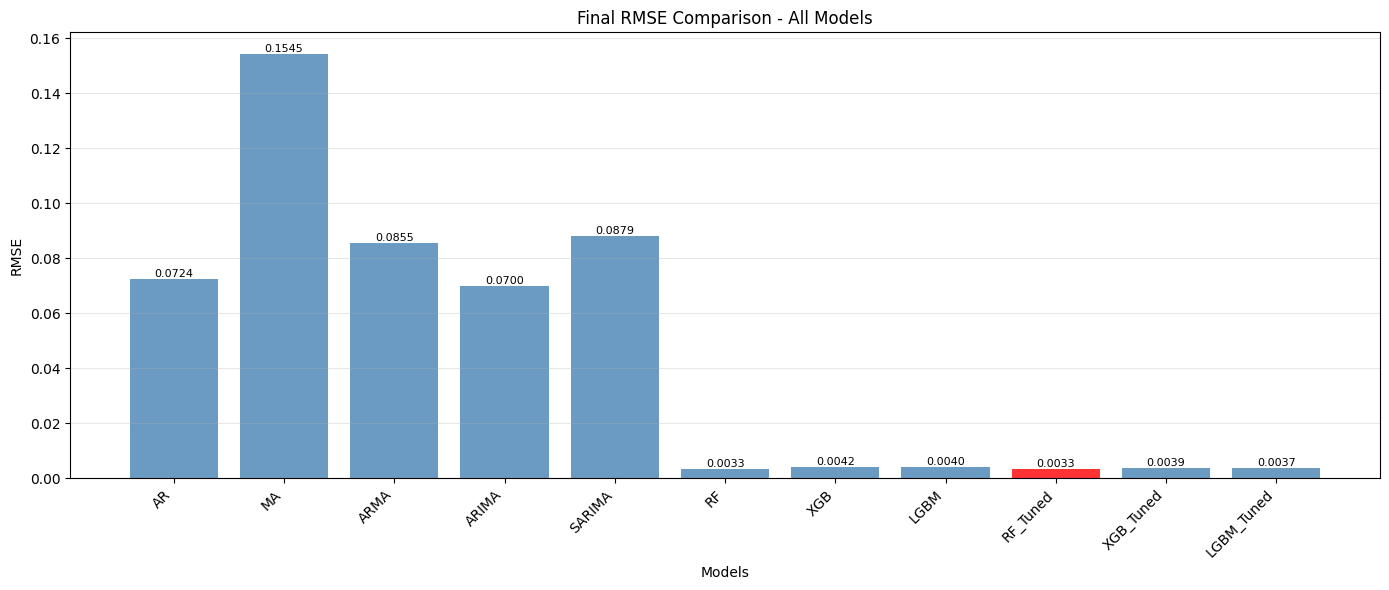

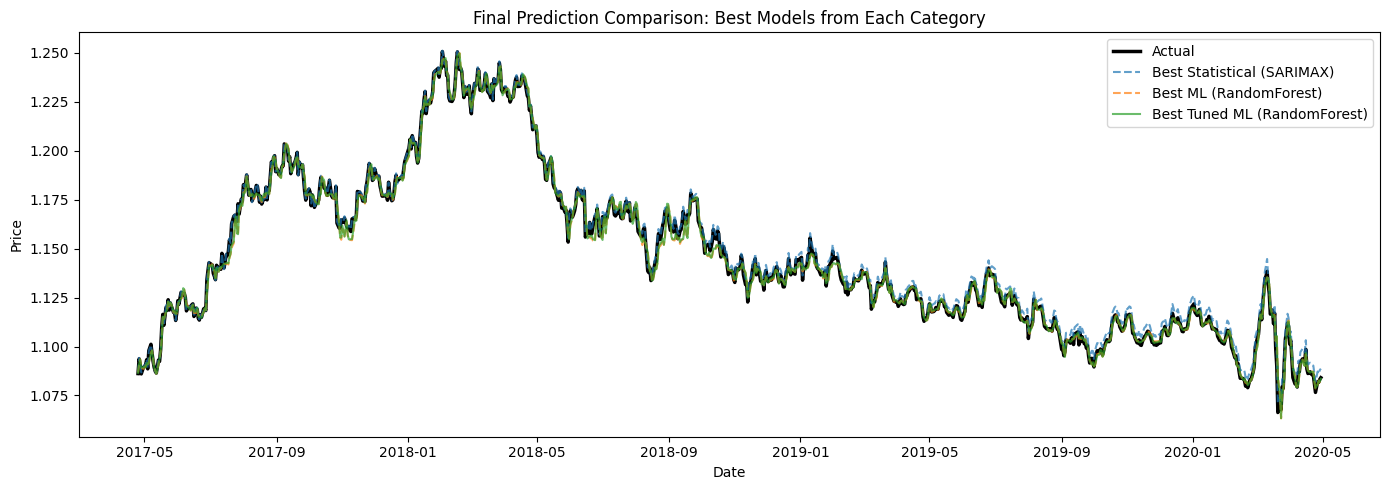


OVERALL BEST MODEL:
Model: RF_Tuned
RMSE: 0.003265

BEST FROM EACH CATEGORY:
Best Statistical Model: SARIMAX (RMSE: 0.002798)
Best ML Model: RandomForest (RMSE: 0.003346)
Best Tuned ML Model: RandomForest (RMSE: 0.003265)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== TASK 1: Combine all RMSE =====
final_rmse = {
    "AR": baseline_rmse["AR"],
    "MA": baseline_rmse["MA"],
    "ARMA": baseline_rmse["ARMA"],
    "ARIMA": baseline_rmse["ARIMA"],
    "SARIMA": baseline_rmse["SARIMA"],
    "RF": ml_rmse["RandomForest"],
    "XGB": ml_rmse["XGBoost"],
    "LGBM": ml_rmse["LightGBM"],
    "RF_Tuned": tuned_ml_rmse["RandomForest"],
    "XGB_Tuned": tuned_ml_rmse["XGBoost"],
    "LGBM_Tuned": tuned_ml_rmse["LightGBM"]
}

# ===== TASK 2: Find best model =====
best_model = min(final_rmse, key=final_rmse.get)
best_rmse = final_rmse[best_model]

print("\n" + "="*60)
print("FINAL RESULTS:")
print("="*60)
print(f"Best Model: {best_model}")
print(f"Best RMSE: {best_rmse:.6f}")
print("\n" + "="*60)
print("All Models RMSE:")
print("="*60)
for model, rmse in sorted(final_rmse.items(), key=lambda x: x[1]):
    print(f"{model}: {rmse:.6f}")

# ===== TASK 3: Bar chart of all models =====
fig, ax = plt.subplots(figsize=(14, 6))

models_list = list(final_rmse.keys())
rmse_values = list(final_rmse.values())

# Color the best model differently
colors = ['red' if model == best_model else 'steelblue' for model in models_list]

bars = ax.bar(models_list, rmse_values, color=colors, alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax.set_title('Final RMSE Comparison - All Models')
ax.grid(axis='y', alpha=0.3)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ===== TASK 4: Final prediction comparison plot =====
# Identify best models from each category
best_stat_model = best_baseline_model
best_ml_model = min(ml_rmse, key=ml_rmse.get)
best_ml_tuned_model = min(tuned_ml_rmse, key=tuned_ml_rmse.get)

# Get predictions based on best models
if best_stat_model == "AR":
    best_stat_pred = predictions_ar_opt
elif best_stat_model == "MA":
    best_stat_pred = predictions_ma_opt
elif best_stat_model == "ARMA":
    best_stat_pred = predictions_arma_opt
elif best_stat_model == "ARIMA":
    best_stat_pred = predictions_arima_opt
elif best_stat_model == "SARIMA":
    best_stat_pred = predictions_sarima_opt
elif best_stat_model == "SARIMAX":
    best_stat_pred = sarimax_pred

# Align best_stat_pred to match the length and index of y_test
# best_stat_pred starts one day earlier and has one more entry than y_test
# We will drop the first entry of best_stat_pred to align it.
best_stat_pred_aligned = best_stat_pred.iloc[1:]

if best_ml_model == "RandomForest":
    best_ml_pred = predictions_rf
elif best_ml_model == "XGBoost":
    best_ml_pred = predictions_xgb
elif best_ml_model == "LightGBM":
    best_ml_pred = predictions_lgbm

if best_ml_tuned_model == "RandomForest":
    best_ml_tuned_pred = predictions_rf_opt
elif best_ml_tuned_model == "XGBoost":
    best_ml_tuned_pred = predictions_xgb_opt
elif best_ml_tuned_model == "LightGBM":
    best_ml_tuned_pred = predictions_lgbm_opt

# Use test_index_ml for ML models alignment
plt.figure(figsize=(14, 5))
plt.plot(test_index_ml, y_test.values, label='Actual', linewidth=2.5, color='black')
plt.plot(test_index_ml, best_stat_pred_aligned.values, label=f'Best Statistical ({best_stat_model})',
         linewidth=1.5, alpha=0.7, linestyle='--')
plt.plot(test_index_ml, best_ml_pred, label=f'Best ML ({best_ml_model})',
         linewidth=1.5, alpha=0.7, linestyle='--')
plt.plot(test_index_ml, best_ml_tuned_pred, label=f'Best Tuned ML ({best_ml_tuned_model})',
         linewidth=1.5, alpha=0.7)
plt.title('Final Prediction Comparison: Best Models from Each Category')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# ===== Summary =====
print("\n" + "="*60)
print("OVERALL BEST MODEL:")
print("="*60)
print(f"Model: {best_model}")
print(f"RMSE: {best_rmse:.6f}")
print("\n" + "="*60)
print("BEST FROM EACH CATEGORY:")
print("="*60)
print(f"Best Statistical Model: {best_stat_model} (RMSE: {baseline_rmse[best_stat_model]:.6f})")
print(f"Best ML Model: {best_ml_model} (RMSE: {ml_rmse[best_ml_model]:.6f})")
print(f"Best Tuned ML Model: {best_ml_tuned_model} (RMSE: {tuned_ml_rmse[best_ml_tuned_model]:.6f})")


COMPREHENSIVE METRICS FOR ALL MODELS:

RF_Tuned:
  RMSE: 0.003265
  MAE:  0.002303
  MAPE: 0.1999%

RF:
  RMSE: 0.003346
  MAE:  0.002374
  MAPE: 0.2062%

LGBM_Tuned:
  RMSE: 0.003715
  MAE:  0.002596
  MAPE: 0.2253%

XGB_Tuned:
  RMSE: 0.003877
  MAE:  0.002707
  MAPE: 0.2351%

LGBM:
  RMSE: 0.003989
  MAE:  0.002848
  MAPE: 0.2474%

XGB:
  RMSE: 0.004204
  MAE:  0.003011
  MAPE: 0.2617%

ARMA:
  RMSE: 0.064558
  MAE:  0.056491
  MAPE: 4.9322%

AR:
  RMSE: 0.067935
  MAE:  0.059389
  MAPE: 5.1978%

ARIMA:
  RMSE: 0.070043
  MAE:  0.057237
  MAPE: 4.8747%

SARIMA:
  RMSE: 0.070178
  MAE:  0.057394
  MAPE: 4.8884%

MA:
  RMSE: 0.152694
  MAE:  0.147020
  MAPE: 12.9648%


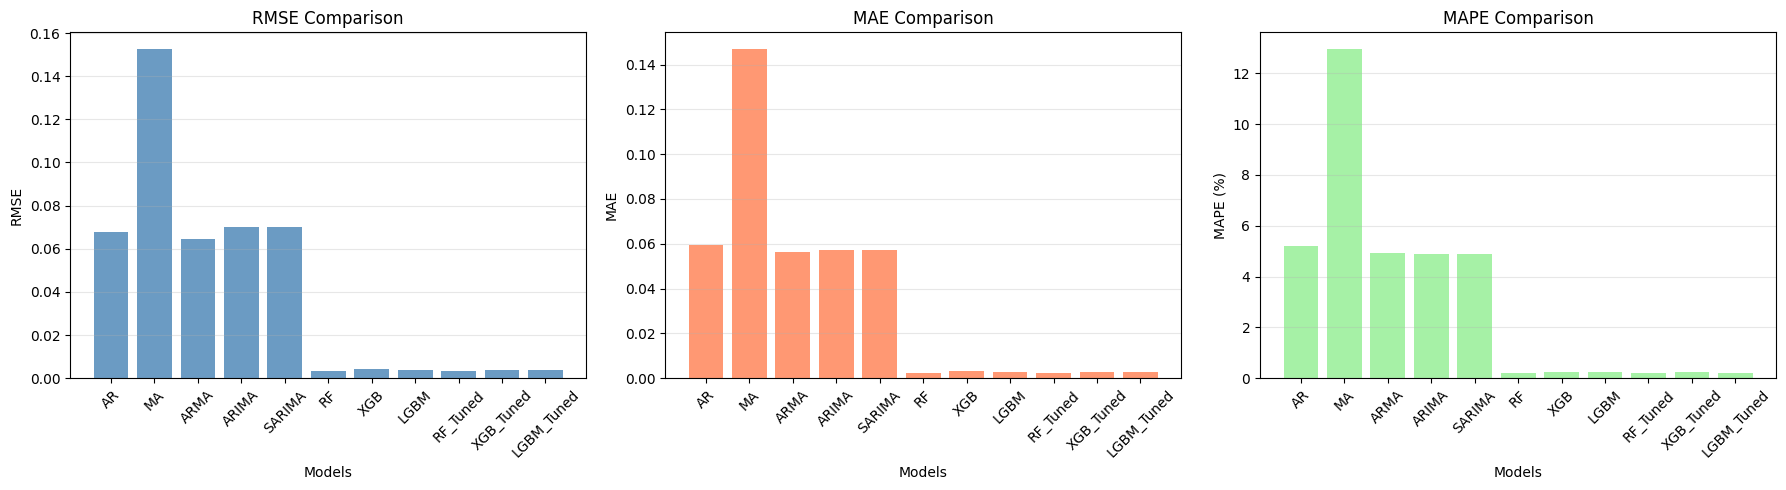


BEST MODELS BY METRIC:
Best RMSE Model: RF_Tuned (0.003265)
Best MAE Model:  RF_Tuned (0.002303)
Best MAPE Model: RF_Tuned (0.1999%)


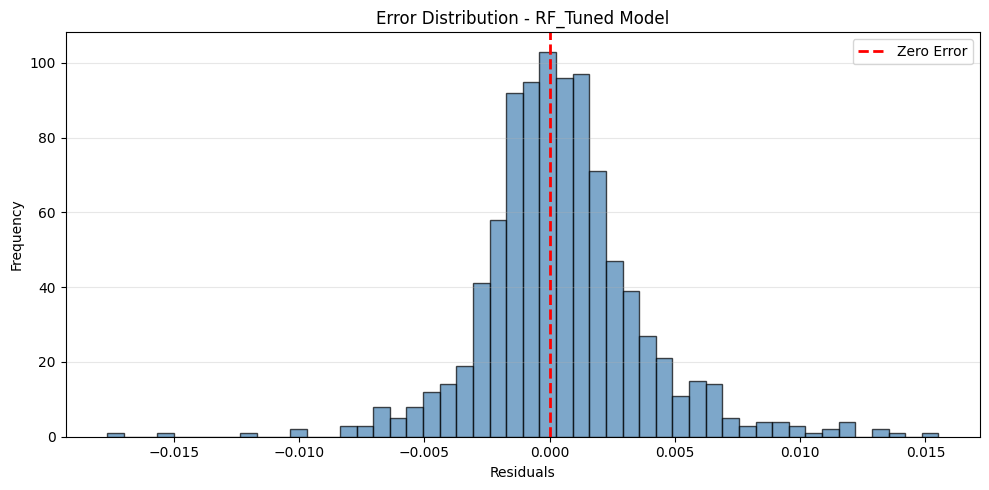

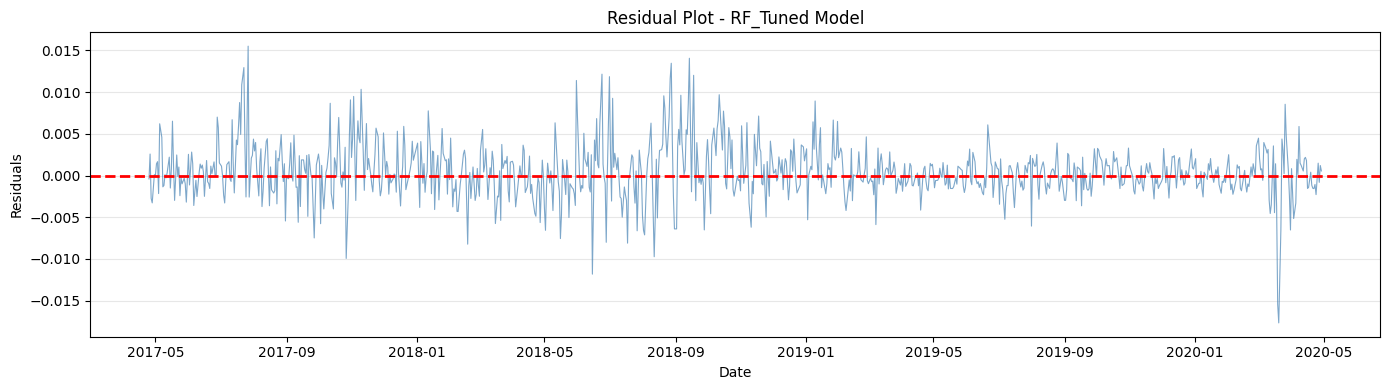

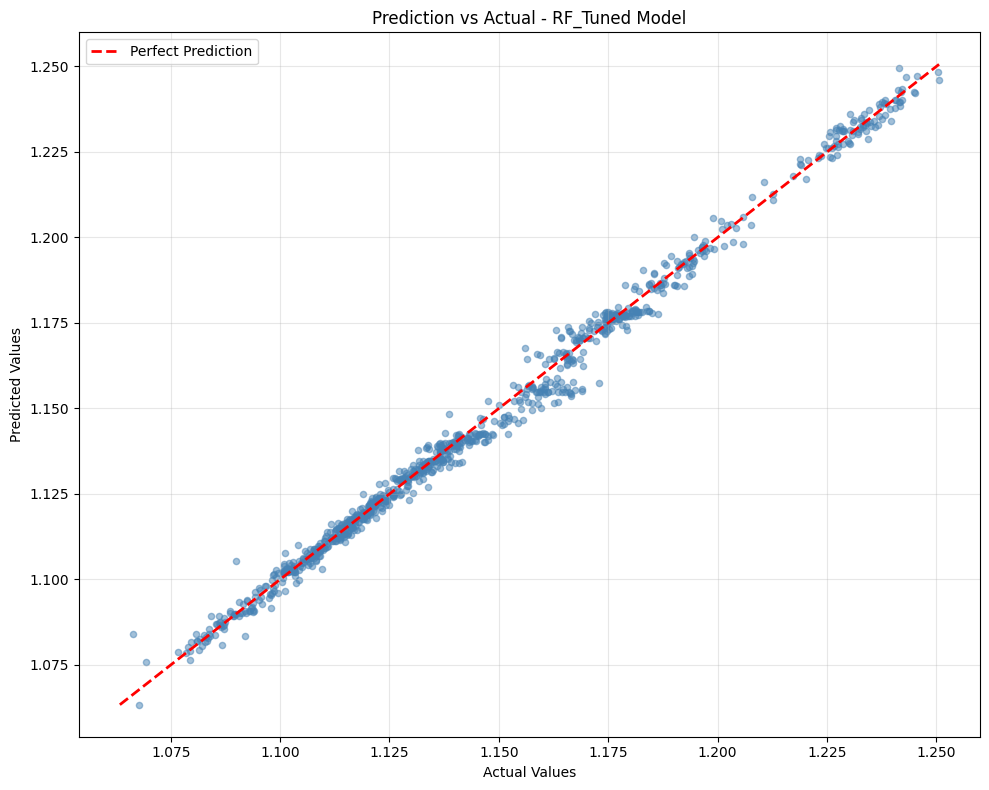


DETAILED ANALYSIS FOR BEST MODEL: RF_Tuned
Mean Residual: 0.000467
Std Dev Residual: 0.003232
Min Residual: -0.017664
Max Residual: 0.015517

RMSE: 0.003265
MAE:  0.002303
MAPE: 0.1999%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# ===== TASK 1 & 2: Compute metrics for all models =====

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Dictionary to store all predictions aligned to test_index_ml
# Note: y_test (from ML split) has length 934.
# Statistical model predictions (e.g., predictions_ar_opt) have length 935.
# We will slice statistical predictions to match y_test length (934).
all_predictions = {
    "AR": predictions_ar_opt.values,
    "MA": predictions_ma_opt.values,
    "ARMA": predictions_arma_opt.values,
    "ARIMA": predictions_arima_opt.values,
    "SARIMA": predictions_sarima_opt.values,
    "RF": predictions_rf,
    "XGB": predictions_xgb,
    "LGBM": predictions_lgbm,
    "RF_Tuned": predictions_rf_opt,
    "XGB_Tuned": predictions_xgb_opt,
    "LGBM_Tuned": predictions_lgbm_opt
}

metrics = {}

for model_name, predictions_full in all_predictions.items():
    # Check if the prediction length matches y_test length
    if len(predictions_full) != len(y_test):
        # For statistical models, predictions are typically one element longer, so slice the first one.
        # This assumes the start date of statistical predictions is one step before ML test data.
        predictions_aligned = predictions_full[1:]
    else:
        predictions_aligned = predictions_full

    rmse = sqrt(mean_squared_error(y_test.values, predictions_aligned))
    mae = mean_absolute_error(y_test.values, predictions_aligned)
    mape = calculate_mape(y_test.values, predictions_aligned)

    metrics[model_name] = {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

print("\n" + "="*70)
print("COMPREHENSIVE METRICS FOR ALL MODELS:")
print("="*70)
for model, metric_values in sorted(metrics.items(), key=lambda x: x[1]["RMSE"]):
    print(f"\n{model}:")
    print(f"  RMSE: {metric_values['RMSE']:.6f}")
    print(f"  MAE:  {metric_values['MAE']:.6f}")
    print(f"  MAPE: {metric_values['MAPE']:.4f}%")

# ===== TASK 3a: Bar plots for RMSE, MAE, MAPE =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_list = list(metrics.keys())
rmse_values = [metrics[m]["RMSE"] for m in models_list]
mae_values = [metrics[m]["MAE"] for m in models_list]
mape_values = [metrics[m]["MAPE"] for m in models_list]

# RMSE Bar plot
axes[0].bar(models_list, rmse_values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Models')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Comparison')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# MAE Bar plot
axes[1].bar(models_list, mae_values, color='coral', alpha=0.8)
axes[1].set_xlabel('Models')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Comparison')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# MAPE Bar plot
axes[2].bar(models_list, mape_values, color='lightgreen', alpha=0.8)
axes[2].set_xlabel('Models')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE Comparison')
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ===== Find best models based on each metric =====
best_rmse_model = min(metrics, key=lambda x: metrics[x]["RMSE"])
best_mae_model = min(metrics, key=lambda x: metrics[x]["MAE"])
best_mape_model = min(metrics, key=lambda x: metrics[x]["MAPE"])

print("\n" + "="*70)
print("BEST MODELS BY METRIC:")
print("="*70)
print(f"Best RMSE Model: {best_rmse_model} ({metrics[best_rmse_model]['RMSE']:.6f})")
print(f"Best MAE Model:  {best_mae_model} ({metrics[best_mae_model]['MAE']:.6f})")
print(f"Best MAPE Model: {best_mape_model} ({metrics[best_mape_model]['MAPE']:.4f}%)")

# Use best RMSE model for detailed analysis
best_model_for_analysis = best_rmse_model
best_predictions = all_predictions[best_model_for_analysis]
# Ensure best_predictions is aligned for analysis as well
if len(best_predictions) != len(y_test):
    best_predictions_aligned = best_predictions[1:]
else:
    best_predictions_aligned = best_predictions

residuals = y_test.values - best_predictions_aligned

# ===== TASK 3b: Error distribution (histogram) =====
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title(f'Error Distribution - {best_model_for_analysis} Model')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ===== TASK 3c: Residual plot (time series) =====
plt.figure(figsize=(14, 4))
plt.plot(test_index_ml, residuals, linewidth=0.8, color='steelblue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title(f'Residual Plot - {best_model_for_analysis} Model')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ===== TASK 3d: Prediction vs Actual scatter plot =====
plt.figure(figsize=(10, 8))
plt.scatter(y_test.values, best_predictions_aligned, alpha=0.5, s=20, color='steelblue')

# Add diagonal reference line (perfect prediction)
min_val = min(y_test.min(), best_predictions_aligned.min())
max_val = max(y_test.max(), best_predictions_aligned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Prediction vs Actual - {best_model_for_analysis} Model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== Summary Statistics =====
print("\n" + "="*70)
print(f"DETAILED ANALYSIS FOR BEST MODEL: {best_model_for_analysis}")
print("="*70)
print(f"Mean Residual: {np.mean(residuals):.6f}")
print(f"Std Dev Residual: {np.std(residuals):.6f}")
print(f"Min Residual: {np.min(residuals):.6f}")
print(f"Max Residual: {np.max(residuals):.6f}")
print(f"\nRMSE: {metrics[best_model_for_analysis]['RMSE']:.6f}")
print(f"MAE:  {metrics[best_model_for_analysis]['MAE']:.6f}")
print(f"MAPE: {metrics[best_model_for_analysis]['MAPE']:.4f}%")


DIRECTION PREDICTION ACCURACY FOR ALL MODELS:
RF_Tuned: 74.71%
RF: 73.85%
XGB_Tuned: 72.56%
LGBM_Tuned: 70.95%
XGB: 69.56%
LGBM: 69.45%
MA: 50.80%
AR: 49.62%
ARMA: 49.62%
ARIMA: 49.41%
SARIMA: 49.41%

BEST MODEL BY DIRECTION ACCURACY: RF_Tuned (74.71%)


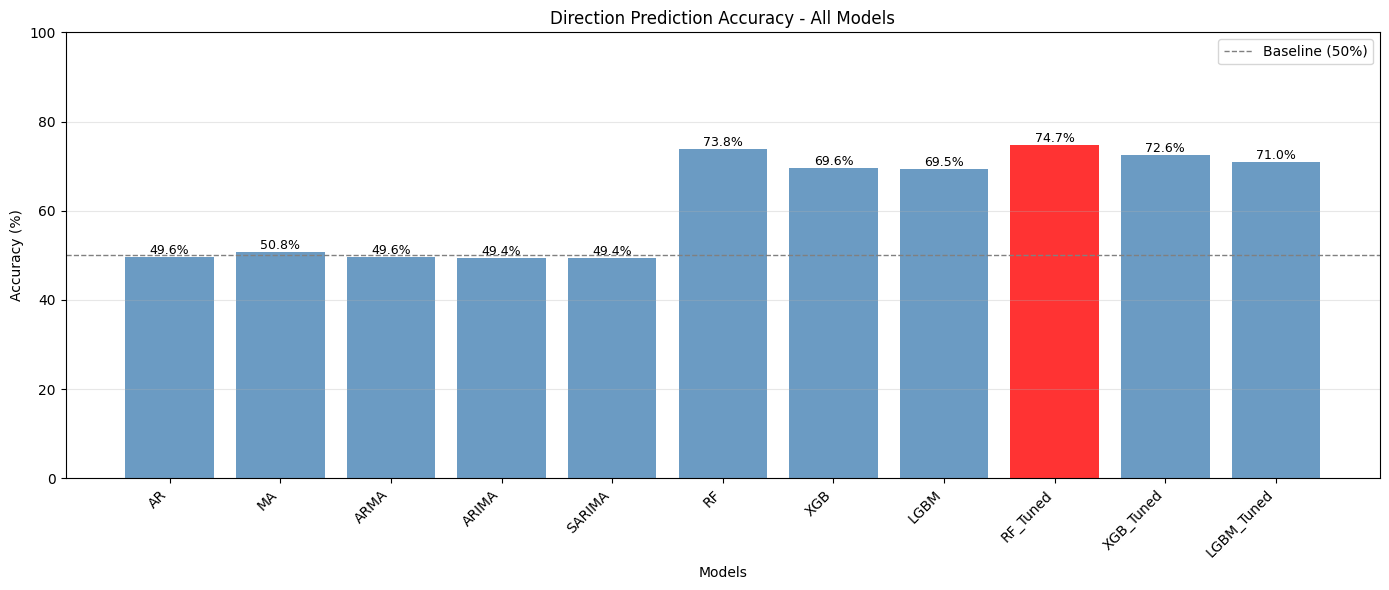

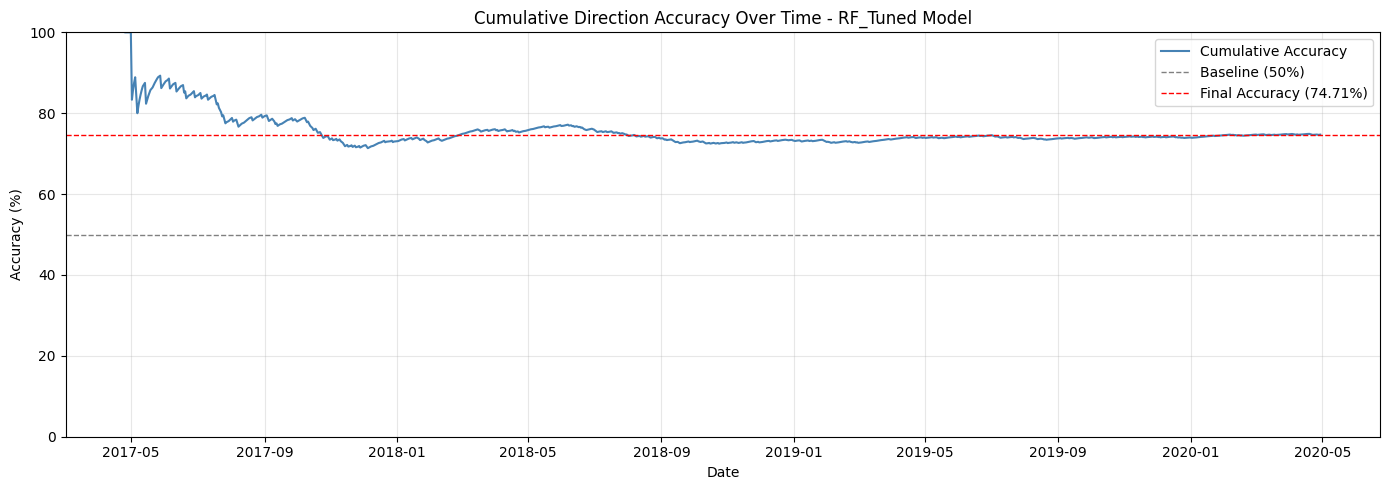


DETAILED ANALYSIS FOR BEST MODEL: RF_Tuned
Total Predictions: 933
Correct Directions: 697
Incorrect Directions: 236
Final Accuracy: 74.71%
Baseline Accuracy (random): 50.00%
Improvement over baseline: 24.71%

COMPARISON: ACCURACY vs RMSE
Best Accuracy Model: RF_Tuned (74.71%)
Best RMSE Model: RF_Tuned (RMSE: 0.003265)
Are they the same? Yes


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===== TASK 1 & 2: Compute direction accuracy for all models =====

def calculate_direction_accuracy(y_true, y_pred):
    """
    Calculate accuracy of direction prediction (up/down)
    """
    # Compute actual direction (1: up, -1: down, 0: no change)
    actual_direction = np.sign(np.diff(y_true))

    # Compute predicted direction
    # For each prediction, compare with previous actual value
    predicted_direction = np.sign(y_pred[1:] - y_true[:-1])

    # Calculate accuracy (matching directions)
    matches = np.sum(actual_direction == predicted_direction)
    total = len(actual_direction)
    accuracy = (matches / total) * 100

    return accuracy, actual_direction, predicted_direction

# Dictionary to store all predictions
all_predictions = {
    "AR": predictions_ar_opt.values,
    "MA": predictions_ma_opt.values,
    "ARMA": predictions_arma_opt.values,
    "ARIMA": predictions_arima_opt.values,
    "SARIMA": predictions_sarima_opt.values,
    "RF": predictions_rf,
    "XGB": predictions_xgb,
    "LGBM": predictions_lgbm,
    "RF_Tuned": predictions_rf_opt,
    "XGB_Tuned": predictions_xgb_opt,
    "LGBM_Tuned": predictions_lgbm_opt
}

accuracy_results = {}
direction_data = {}

for model_name, predictions_full in all_predictions.items():
    # Check if the prediction length matches y_test length
    if len(predictions_full) != len(y_test.values):
        # For statistical models, predictions are typically one element longer, so slice the first one.
        # This assumes the start date of statistical predictions is one step before ML test data.
        predictions_aligned = predictions_full[1:]
    else:
        predictions_aligned = predictions_full

    accuracy, actual_dir, predicted_dir = calculate_direction_accuracy(y_test.values, predictions_aligned)
    accuracy_results[model_name] = accuracy
    direction_data[model_name] = {
        "actual": actual_dir,
        "predicted": predicted_dir
    }

# ===== TASK 3: Print results =====
print("\n" + "="*70)
print("DIRECTION PREDICTION ACCURACY FOR ALL MODELS:")
print("="*70)
for model, acc in sorted(accuracy_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {acc:.2f}%")

# Find best model based on accuracy
best_accuracy_model = max(accuracy_results, key=accuracy_results.get)
best_accuracy_value = accuracy_results[best_accuracy_model]

print("\n" + "="*70)
print(f"BEST MODEL BY DIRECTION ACCURACY: {best_accuracy_model} ({best_accuracy_value:.2f}%)")
print("="*70)

# ===== TASK 4: Bar chart of accuracy =====
fig, ax = plt.subplots(figsize=(14, 6))

models_list = list(accuracy_results.keys())
accuracy_values = list(accuracy_results.values())

# Color the best model differently
colors = ['red' if model == best_accuracy_model else 'steelblue' for model in models_list]

bars = ax.bar(models_list, accuracy_values, color=colors, alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Direction Prediction Accuracy - All Models')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Baseline (50%)')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

# ===== TASK 5: Cumulative accuracy over time for best model =====
best_actual_dir = direction_data[best_accuracy_model]["actual"]
best_predicted_dir = direction_data[best_accuracy_model]["predicted"]

# Compute running accuracy
matches = (best_actual_dir == best_predicted_dir).astype(int)
cumsum_matches = np.cumsum(matches)
cumsum_total = np.arange(1, len(matches) + 1)
cumulative_accuracy = (cumsum_matches / cumsum_total) * 100

# Create time index for cumulative plot
cumulative_index = test_index_ml[1:]  # Skip first value since we use diff

plt.figure(figsize=(14, 5))
plt.plot(cumulative_index, cumulative_accuracy, linewidth=1.5, color='steelblue', label='Cumulative Accuracy')
plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Baseline (50%)')
plt.axhline(y=best_accuracy_value, color='red', linestyle='--', linewidth=1, label=f'Final Accuracy ({best_accuracy_value:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Accuracy (%)')
plt.title(f'Cumulative Direction Accuracy Over Time - {best_accuracy_model} Model')
plt.ylim([0, 100])
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== Additional Analysis =====
print("\n" + "="*70)
print(f"DETAILED ANALYSIS FOR BEST MODEL: {best_accuracy_model}")
print("="*70)
print(f"Total Predictions: {len(best_actual_dir)}")
print(f"Correct Directions: {np.sum(matches)}")
print(f"Incorrect Directions: {len(matches) - np.sum(matches)}")
print(f"Final Accuracy: {best_accuracy_value:.2f}%")
print(f"Baseline Accuracy (random): 50.00%")
print(f"Improvement over baseline: {best_accuracy_value - 50:.2f}%")

# Comparison with other metrics
print("\n" + "="*70)
print("COMPARISON: ACCURACY vs RMSE")
print("="*70)
print(f"Best Accuracy Model: {best_accuracy_model} ({best_accuracy_value:.2f}%)")
print(f"Best RMSE Model: {best_rmse_model} (RMSE: {metrics[best_rmse_model]['RMSE']:.6f})")
print(f"Are they the same? {'Yes' if best_accuracy_model == best_rmse_model else 'No'}")


TRADING STRATEGY ANALYSIS - RF_Tuned MODEL

----------------------------------------------------------------------
PRECISION METRICS:
----------------------------------------------------------------------
Precision UP:   0.7165 (71.65%)
Precision DOWN: 0.6904 (69.04%)
Recall UP:      0.6878 (68.78%)
Recall DOWN:    0.7190 (71.90%)

----------------------------------------------------------------------
CONFUSION MATRIX:
----------------------------------------------------------------------
                Predicted DOWN  Predicted UP
Actual DOWN           330           129
Actual UP             148           326

----------------------------------------------------------------------
TRADING PERFORMANCE:
----------------------------------------------------------------------
Sharpe Ratio:           -0.1167
Max Drawdown:           -0.0941 (-9.41%)
Final Return:           -0.0228 (-2.28%)
Buy & Hold Return:      -0.0088 (-0.88%)
Avg Daily Return:       -0.000021 (-0.0021%)
Daily Return Std

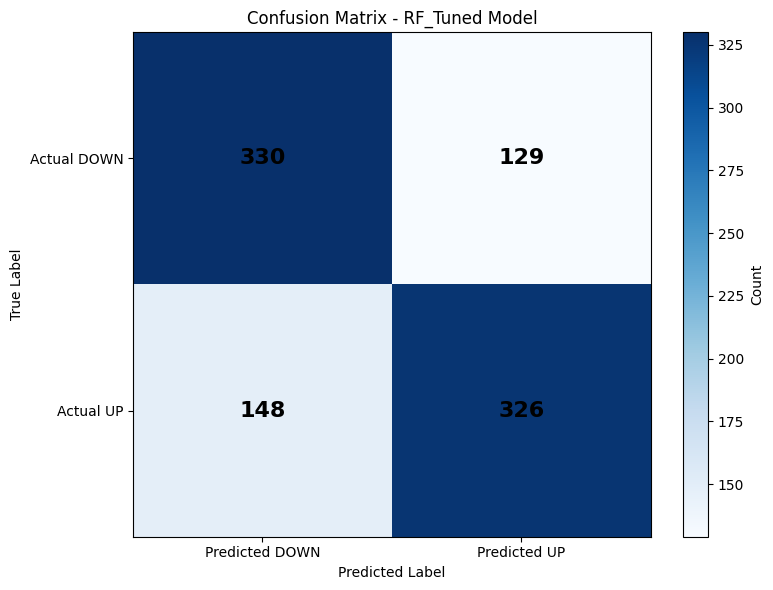

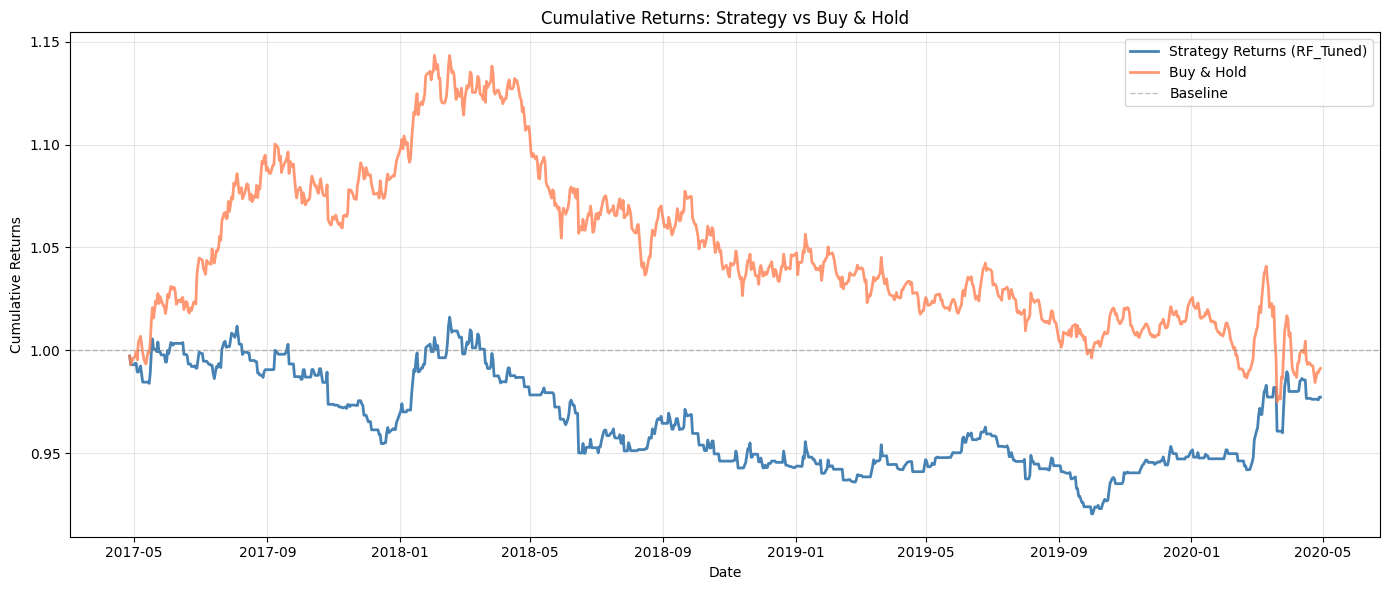


----------------------------------------------------------------------
ADDITIONAL METRICS:
----------------------------------------------------------------------
Total Trades:          933
Upward Predictions:    455
Downward Predictions:  478
Direction Accuracy:    70.31%
Cumulative Return:     -2.28%
Outperformance:        -1.41%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== TASK 1: Convert predictions to direction =====
# Use best RMSE model for predictions
predictions_best = all_predictions[best_rmse_model]
y_test_series = pd.Series(y_test.values, index=test_index_ml)
predictions_best_series = pd.Series(predictions_best, index=test_index_ml)

# Actual direction: 1 if price went up, 0 if down or flat
actual_direction = (y_test_series.diff() > 0).astype(int)

# Predicted direction: 1 if predicted price goes up, 0 if down or flat
predicted_direction = (predictions_best_series.diff() > 0).astype(int)

# Remove first NaN value
actual_direction = actual_direction[1:]
predicted_direction = predicted_direction[1:]
y_test_clean = y_test_series[1:]
predictions_best_clean = predictions_best_series[1:]

# ===== TASK 2: Precision Metrics =====
# True Positives, True Negatives, False Positives, False Negatives
tp = np.sum((actual_direction == 1) & (predicted_direction == 1))
tn = np.sum((actual_direction == 0) & (predicted_direction == 0))
fp = np.sum((actual_direction == 0) & (predicted_direction == 1))
fn = np.sum((actual_direction == 1) & (predicted_direction == 0))

# Precision for UP (predicted UP)
precision_up = tp / (tp + fp) if (tp + fp) > 0 else 0

# Precision for DOWN (predicted DOWN)
precision_down = tn / (tn + fn) if (tn + fn) > 0 else 0

# Recall metrics
recall_up = tp / (tp + fn) if (tp + fn) > 0 else 0
recall_down = tn / (tn + fp) if (tn + fp) > 0 else 0

# ===== TASK 3: Confusion Matrix =====
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

# ===== TASK 4: Trading Strategy =====
# Calculate returns
returns = y_test_clean.pct_change()

# Strategy returns: if predicted UP (1), take positive returns, else take negative returns
# We use shift(1) because we trade based on yesterday's prediction
strategy_returns = returns * predicted_direction.shift(1)

# Remove first NaN from shift
strategy_returns = strategy_returns[1:]
returns = returns[1:]

# Cumulative returns
cumulative_returns = (1 + strategy_returns).cumprod()

# Buy and hold returns (for comparison)
buy_hold_returns = (1 + returns).cumprod()

# ===== TASK 5: Sharpe Ratio =====
mean_return = np.mean(strategy_returns)
std_return = np.std(strategy_returns)
sharpe_ratio = (mean_return / std_return) * np.sqrt(252) if std_return > 0 else 0

# ===== TASK 6: Max Drawdown =====
cumulative_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()

# ===== Print Results =====
print("\n" + "="*70)
print(f"TRADING STRATEGY ANALYSIS - {best_rmse_model} MODEL")
print("="*70)

print("\n" + "-"*70)
print("PRECISION METRICS:")
print("-"*70)
print(f"Precision UP:   {precision_up:.4f} ({precision_up*100:.2f}%)")
print(f"Precision DOWN: {precision_down:.4f} ({precision_down*100:.2f}%)")
print(f"Recall UP:      {recall_up:.4f} ({recall_up*100:.2f}%)")
print(f"Recall DOWN:    {recall_down:.4f} ({recall_down*100:.2f}%)")

print("\n" + "-"*70)
print("CONFUSION MATRIX:")
print("-"*70)
print("                Predicted DOWN  Predicted UP")
print(f"Actual DOWN          {tn:4d}          {fp:4d}")
print(f"Actual UP            {fn:4d}          {tp:4d}")

print("\n" + "-"*70)
print("TRADING PERFORMANCE:")
print("-"*70)
print(f"Sharpe Ratio:           {sharpe_ratio:.4f}")
print(f"Max Drawdown:           {max_drawdown:.4f} ({max_drawdown*100:.2f}%)")
print(f"Final Return:           {(cumulative_returns.iloc[-1] - 1):.4f} ({(cumulative_returns.iloc[-1] - 1)*100:.2f}%)")
print(f"Buy & Hold Return:      {(buy_hold_returns.iloc[-1] - 1):.4f} ({(buy_hold_returns.iloc[-1] - 1)*100:.2f}%)")
print(f"Avg Daily Return:       {mean_return:.6f} ({mean_return*100:.4f}%)")
print(f"Daily Return Std Dev:   {std_return:.6f} ({std_return*100:.4f}%)")

# ===== TASK 7a: Confusion Matrix Heatmap =====
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
im = ax.imshow(confusion_matrix, cmap='Blues', aspect='auto')

# Set ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted DOWN', 'Predicted UP'])
ax.set_yticklabels(['Actual DOWN', 'Actual UP'])

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, confusion_matrix[i, j],
                      ha="center", va="center", color="black", fontsize=16, fontweight='bold')

ax.set_title(f'Confusion Matrix - {best_rmse_model} Model')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count')

plt.tight_layout()
plt.show()

# ===== TASK 7b: Cumulative Returns Curve =====
cumulative_index = cumulative_returns.index

plt.figure(figsize=(14, 6))
plt.plot(cumulative_index, cumulative_returns.values, label=f'Strategy Returns ({best_rmse_model})',
         linewidth=2, color='steelblue')
plt.plot(cumulative_index, buy_hold_returns.values, label='Buy & Hold',
         linewidth=2, color='coral', alpha=0.8)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')

plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns: Strategy vs Buy & Hold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===== Additional Analysis =====
print("\n" + "-"*70)
print("ADDITIONAL METRICS:")
print("-"*70)
total_trades = np.sum(predicted_direction == 1) + np.sum(predicted_direction == 0)
upward_trades = np.sum(predicted_direction == 1)
downward_trades = np.sum(predicted_direction == 0)
win_rate = (np.sum((actual_direction == predicted_direction)) / len(actual_direction)) * 100

print(f"Total Trades:          {total_trades}")
print(f"Upward Predictions:    {upward_trades}")
print(f"Downward Predictions:  {downward_trades}")
print(f"Direction Accuracy:    {win_rate:.2f}%")
print(f"Cumulative Return:     {(cumulative_returns.iloc[-1] - 1)*100:.2f}%")
print(f"Outperformance:        {((cumulative_returns.iloc[-1] / buy_hold_returns.iloc[-1]) - 1)*100:.2f}%")